# Random-Forest Open-Cluster Membership with Gaia DR3 — Analysis
**Author:** Deeshani Mitra 



1. **Generalisation** — apply the identical RF pipeline to 5 additional open clusters spanning a range of distance, richness and field contamination.
2. **Independent validation** — compare RF-selected members against the Hunt & Reffert (2023) Gaia DR3 membership catalogue (independent of the Cantat-Gaudin 2018 labels used for training).
3. **Feature ablation** — retrain with different feature subsets (proper motion / parallax / photometry / position) to show which information actually drives the classification.
4. **Bookkeeping** — an explicit accounting of *catalogue* members (training labels) vs. stars *classified* as members by the RF, using out-of-fold predictions so that no star is scored by a model that was trained on it.



## 0. Imports & settings

In [3]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from astroquery.gaia   import Gaia
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as u

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble        import RandomForestClassifier
from sklearn.inspection      import permutation_importance
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     average_precision_score, roc_auc_score,
                                     precision_score, recall_score, f1_score)

RANDOM_STATE = 42
PROB_THR     = 0.5      
MATCH_RADIUS = 1.0     
OUT_DIR      = 'outputs_extended'
os.makedirs(OUT_DIR, exist_ok=True)

Vizier.ROW_LIMIT = -1
Gaia.ROW_LIMIT   = -1


RF_KW = dict(n_estimators=200, max_depth=10, max_features='sqrt',
             class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

FEATURES_ALL = ['delta_ra', 'delta_dec', 'parallax',
                'pmra', 'pmdec', 'pm_mag',
                'phot_g_mean_mag', 'bp_rp', 'bp_g']
print('Imports OK')

Imports OK


## 1. Cluster sample

NGC 752 is the reference. The additional clusters are chosen to span the parameter space rather than to be "easy":

| Cluster | ~Distance | Character | Why it is a useful test |
|---|---|---|---|
| NGC 752 | 440 pc | intermediate-age, moderately rich | baseline from course report |
| NGC 2632 (Praesepe) | 185 pc | very nearby, large on sky, large proper motion | tests behaviour when the cluster is spread over many degrees |
| NGC 2682 (M67) | 850 pc | old, rich, compact | classic benchmark; well-separated PM clump |
| NGC 6633 | 400 pc | sparse, low-latitude field | low member count, heavier contamination |
| NGC 2516 | 410 pc | young, rich, southern | high member count, different sky region |
| NGC 6791 | 4 kpc | very distant, very rich, old | stress test: small parallax, PM signal compressed toward the field |

Cluster centres and half-number radii ($r_{50}$) are read from the Cantat-Gaudin (2018) cluster table rather than typed in by hand.

In [6]:
CLUSTERS = ['NGC_752', 'NGC_2632', 'NGC_2682', 'NGC_6633', 'NGC_2516', 'NGC_6791']

print('Downloading Cantat-Gaudin 2018 tables ...')
cg_cats = Vizier.get_catalogs('J/A+A/618/A93')
cg_clusters = cg_cats[0].to_pandas()      # Table 1: cluster parameters
cg_members  = cg_cats[1].to_pandas()      # Table 2: per-star memberships
for df_ in (cg_clusters, cg_members):
    if df_['Cluster'].dtype == object:
        df_['Cluster'] = df_['Cluster'].astype(str).str.strip()

def _col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    raise KeyError(f'None of {candidates} in {df.columns.tolist()}')

RA_COL  = _col(cg_clusters, ['RA_ICRS', 'RAJ2000', '_RA'])
DE_COL  = _col(cg_clusters, ['DE_ICRS', 'DEJ2000', '_DE'])
R50_COL = _col(cg_clusters, ['r50'])
DST_COL = _col(cg_clusters, ['dmode', 'DistPc', 'dist'])

cl_info = (cg_clusters[cg_clusters['Cluster'].isin(CLUSTERS)]
           .set_index('Cluster').loc[CLUSTERS, [RA_COL, DE_COL, R50_COL, DST_COL]])
cl_info.columns = ['ra0', 'dec0', 'r50_deg', 'dist_pc']
# Cone radius: a few r50, but never below 1 deg or above 3 deg (query size)
cl_info['radius_deg'] = np.clip(6 * cl_info['r50_deg'], 1.0, 3.0)
cl_info['n_cg_members'] = [ (cg_members['Cluster'] == c).sum() for c in CLUSTERS ]
cl_info

,ra0,dec0,r50_deg,dist_pc,radius_deg,n_cg_members
Cluster,,,,,,
NGC_752,29.223000,37.793999,0.485,441.000000,2.910,253
NGC_2632,130.054001,19.621000,0.985,185.500000,3.000,719
NGC_2682,132.845993,11.814000,0.166,859.099976,1.000,848
NGC_6633,276.845001,6.615000,0.360,391.600006,2.160,233
NGC_2516,119.527000,-60.799999,0.496,408.899994,2.976,1106
NGC_6791,290.221008,37.778000,0.068,4530.799805,1.000,1722


## 2. Pipeline functions 

In [9]:
def query_gaia(ra0, dec0, radius):
    q = f'''
    SELECT source_id, ra, dec, parallax, pmra, pmdec,
           phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra0}, {dec0}, {radius})) = 1
      AND parallax > 0
    '''
    job = Gaia.launch_job_async(q)
    return job.get_results().to_pandas()


def attach_cg_labels(df, cluster):
    '''Sky-match CG2018 (DR2 positions) to DR3 and assign member = PMemb >= PROB_THR.'''
    cg = cg_members[cg_members['Cluster'] == cluster].reset_index(drop=True)
    cat  = SkyCoord(ra=cg['RA_ICRS'].values*u.deg, dec=cg['DE_ICRS'].values*u.deg)
    gaia = SkyCoord(ra=df['ra'].values*u.deg,      dec=df['dec'].values*u.deg)
    idx, d2d, _ = gaia.match_to_catalog_sky(cat)
    matched = d2d < MATCH_RADIUS*u.arcsec
    df = df.copy()
    df['proba_cg'] = 0.0
    df.loc[matched, 'proba_cg'] = cg['PMemb'].values[idx[matched]]
    df['member'] = (df['proba_cg'] >= PROB_THR).astype(int)
    return df, len(cg), int(matched.sum())


def engineer(df, ra0, dec0):
    df = df.copy()
    df['bp_rp']     = df['phot_bp_mean_mag'] - df['phot_rp_mean_mag']
    df['bp_g']      = df['phot_bp_mean_mag'] - df['phot_g_mean_mag']
    df['pm_mag']    = np.hypot(df['pmra'], df['pmdec'])
    df['delta_ra']  = (df['ra'] - ra0) * np.cos(np.radians(dec0))
    df['delta_dec'] = df['dec'] - dec0
    return df.dropna(subset=FEATURES_ALL + ['member']).reset_index(drop=True)


def evaluate(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return dict(precision=precision_score(y_true, y_pred, zero_division=0),
                recall=recall_score(y_true, y_pred, zero_division=0),
                f1=f1_score(y_true, y_pred, zero_division=0),
                AP=average_precision_score(y_true, y_prob),
                ROC_AUC=roc_auc_score(y_true, y_prob),
                TP=int(cm[1,1]), FP=int(cm[0,1]), FN=int(cm[1,0]), TN=int(cm[0,0]))


def train_rf(X, y, features):
    Xtr, Xte, ytr, yte = train_test_split(X[features], y, test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=y)
    rf = RandomForestClassifier(**RF_KW).fit(Xtr, ytr)
    prob = rf.predict_proba(Xte)[:, 1]
    return rf, evaluate(yte, (prob >= 0.5).astype(int), prob), (Xtr, Xte, ytr, yte)


def oof_probabilities(X, y, features, n_splits=5):
    '''Out-of-fold RF probability for EVERY star (no star scored by a model trained on it).'''
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_predict(RandomForestClassifier(**RF_KW), X[features], y,
                             cv=skf, method='predict_proba', n_jobs=-1)[:, 1]
print('Functions defined')

Functions defined


## 3. Item 1 — Run the pipeline on all clusters

For each cluster: Gaia DR3 cone search → CG2018 labels → features → 80/20 stratified split → RF (same hyper-parameters as NGC 752) → held-out test metrics. Results are cached to disk so the (slow) Gaia queries only run once.

In [12]:
data = {}       # cluster -> engineered DataFrame
models = {}     # cluster -> fitted RF (full feature set)
rows = []

for cl in CLUSTERS:
    info = cl_info.loc[cl]
    cache = f'{OUT_DIR}/{cl}_gaia.parquet'
    t0 = time.time()
    if os.path.exists(cache):
        raw = pd.read_parquet(cache)
    else:
        raw = query_gaia(info.ra0, info.dec0, info.radius_deg)
        raw.to_parquet(cache)
    raw, n_cat, n_matched = attach_cg_labels(raw, cl)
    df = engineer(raw, info.ra0, info.dec0)
    data[cl] = df

    X, y = df[FEATURES_ALL], df['member']
    rf, m, split = train_rf(X, y, FEATURES_ALL)
    models[cl] = rf
    rows.append(dict(cluster=cl, dist_pc=info.dist_pc, radius_deg=info.radius_deg,
                     n_stars=len(df), n_cat_members=n_cat, n_matched=n_matched,
                     n_label1=int(y.sum()), imbalance=int((y==0).sum()/max(y.sum(),1)),
                     n_test_members=int(split[3].sum()), **m))
    print(f'{cl:10s} {len(df):>8,} stars | {int(y.sum()):>4} labelled members '
          f'| F1={m["f1"]:.2f} AP={m["AP"]:.2f} FP={m["FP"]} FN={m["FN"]}  ({time.time()-t0:.0f}s)')

multi = pd.DataFrame(rows).set_index('cluster')
multi.to_csv(f'{OUT_DIR}/item1_multicluster_metrics.csv')
multi[['dist_pc','n_stars','n_cat_members','n_label1','imbalance','n_test_members',
       'precision','recall','f1','AP','ROC_AUC','TP','FP','FN']].round(3)

NGC_752     194,494 stars |  245 labelled members | F1=0.93 AP=0.99 FP=6 FN=1  (3s)
NGC_2632    113,841 stars |  706 labelled members | F1=0.90 AP=0.93 FP=28 FN=3  (1s)
NGC_2682     14,791 stars |  754 labelled members | F1=0.91 AP=0.93 FP=26 FN=3  (0s)
NGC_6633   1,525,454 stars |  209 labelled members | F1=0.88 AP=0.89 FP=10 FN=1  (26s)
NGC_2516    598,093 stars |  913 labelled members | F1=0.83 AP=0.82 FP=72 FN=1  (11s)
NGC_6791    158,471 stars | 1623 labelled members | F1=0.96 AP=0.97 FP=21 FN=7  (3s)


,dist_pc,n_stars,n_cat_members,n_label1,imbalance,n_test_members,precision,recall,f1,AP,ROC_AUC,TP,FP,FN
cluster,,,,,,,,,,,,,,
NGC_752,441.0,194494,253,245,792,49,0.889,0.980,0.932,0.988,1.000,48,6,1
NGC_2632,185.5,113841,719,706,160,141,0.831,0.979,0.899,0.929,1.000,138,28,3
NGC_2682,859.1,14791,848,754,18,151,0.851,0.980,0.911,0.932,0.998,148,26,3
NGC_6633,391.6,1525454,233,209,7297,42,0.804,0.976,0.882,0.886,1.000,41,10,1
NGC_2516,408.9,598093,1106,913,654,183,0.717,0.995,0.833,0.823,1.000,182,72,1
NGC_6791,4530.8,158471,1722,1623,96,325,0.938,0.978,0.958,0.968,1.000,318,21,7


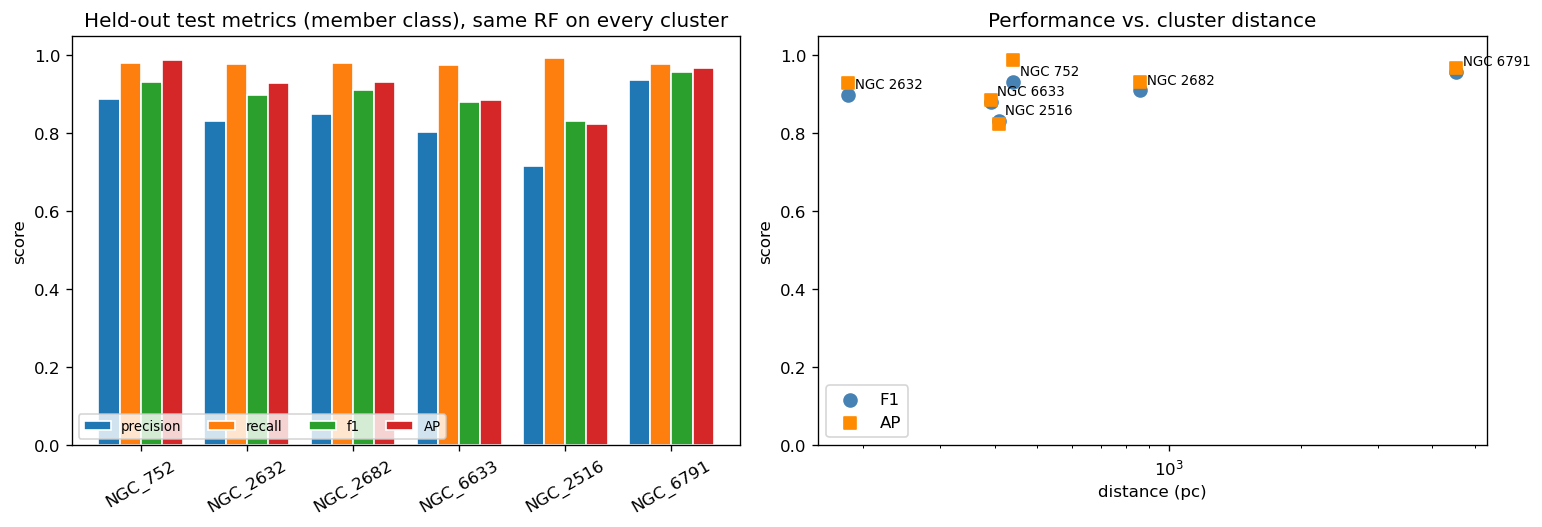

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
multi[['precision','recall','f1','AP']].plot(kind='bar', ax=ax, width=0.8, edgecolor='white')
ax.set_ylim(0, 1.05); ax.set_ylabel('score'); ax.set_xlabel('')
ax.set_title('Held-out test metrics (member class), same RF on every cluster')
ax.legend(ncol=4, fontsize=8, loc='lower left'); ax.tick_params(axis='x', rotation=30)

ax = axes[1]
ax.scatter(multi['dist_pc'], multi['f1'], s=60, c='steelblue', label='F1')
ax.scatter(multi['dist_pc'], multi['AP'], s=60, c='darkorange', marker='s', label='AP')
for cl, r in multi.iterrows():
    ax.annotate(cl.replace('_',' '), (r.dist_pc, r.f1), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.set_xscale('log'); ax.set_xlabel('distance (pc)'); ax.set_ylabel('score'); ax.set_ylim(0,1.05)
ax.set_title('Performance vs. cluster distance'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item1_multicluster.png', dpi=150); plt.show()

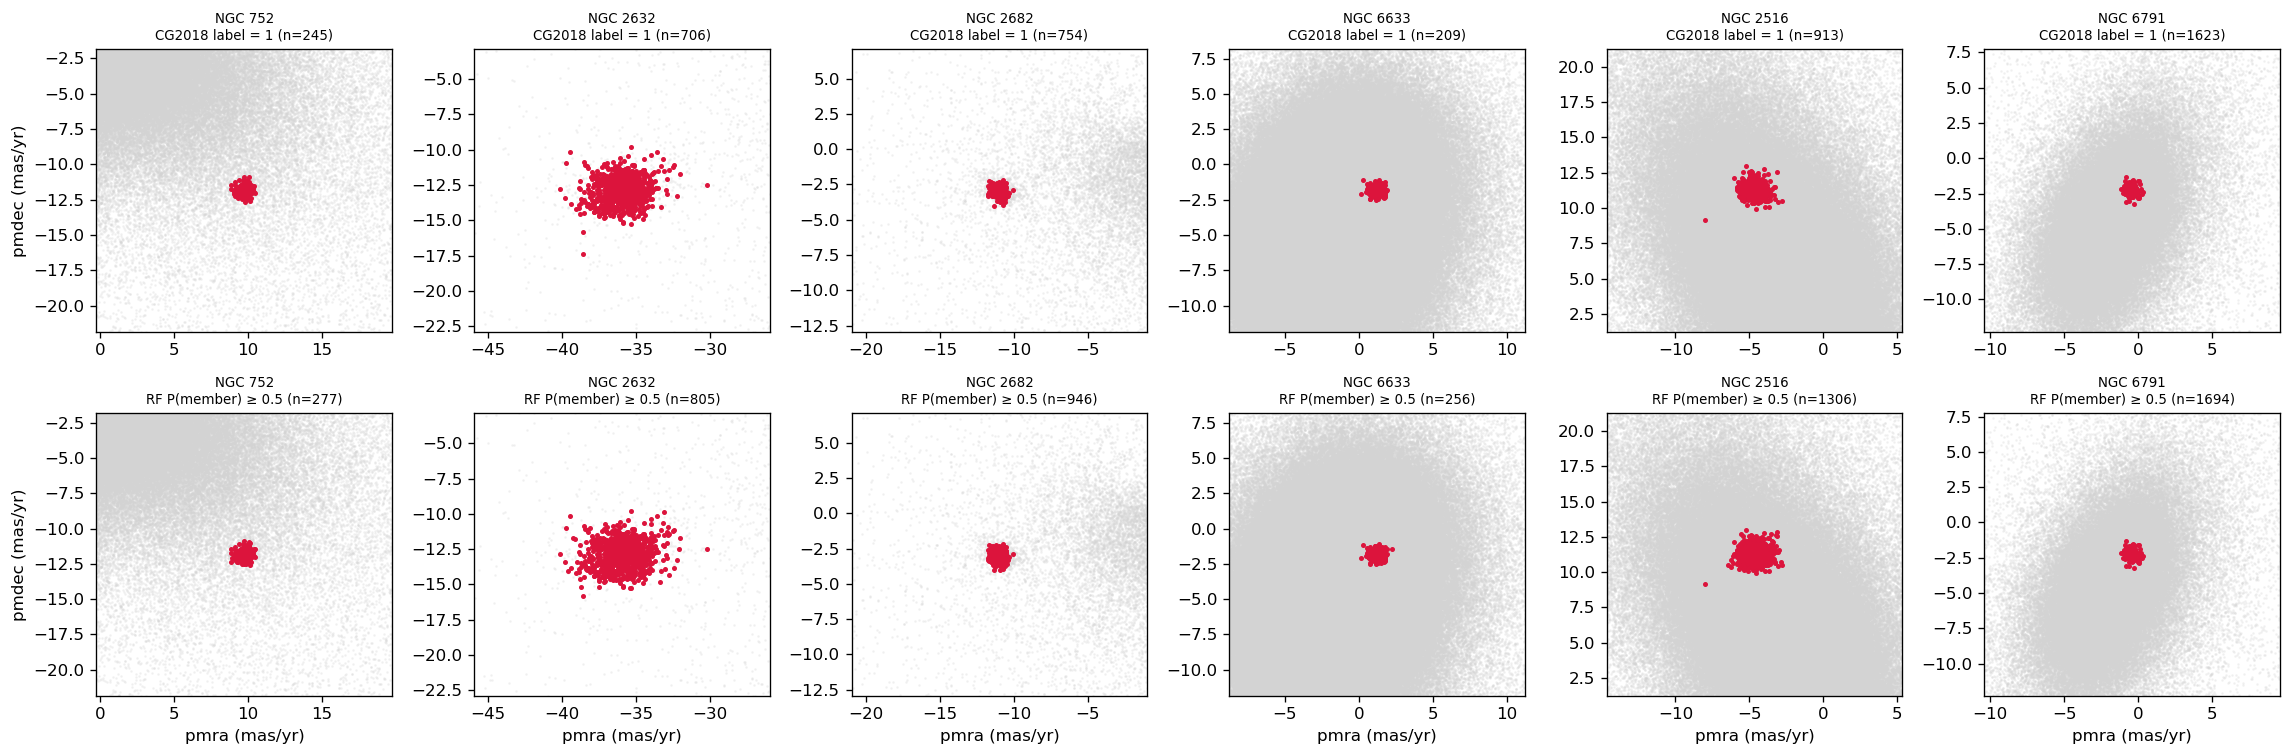

Note: the bottom row is scored in-sample for visual purposes only; quantitative numbers use the held-out test set (Item 1) or out-of-fold predictions (Item 4).


In [16]:

n = len(CLUSTERS); fig, axes = plt.subplots(2, n, figsize=(3.2*n, 6.4))
for j, cl in enumerate(CLUSTERS):
    df = data[cl]; prob = models[cl].predict_proba(df[FEATURES_ALL])[:,1]
    mem = df['member'] == 1
    for i, (mask, ttl) in enumerate([(mem, 'CG2018 label = 1'), (prob >= 0.5, 'RF P(member) ≥ 0.5')]):
        ax = axes[i, j]
        ax.scatter(df['pmra'], df['pmdec'], s=0.3, c='lightgrey', alpha=0.3, rasterized=True)
        ax.scatter(df.loc[mask,'pmra'], df.loc[mask,'pmdec'], s=4, c='crimson')
        c = df.loc[mem, ['pmra','pmdec']].median()
        ax.set_xlim(c.pmra-10, c.pmra+10); ax.set_ylim(c.pmdec-10, c.pmdec+10)
        ax.set_title(f'{cl.replace("_"," ")}\n{ttl} (n={int(mask.sum())})', fontsize=8)
        if j == 0: ax.set_ylabel('pmdec (mas/yr)')
        if i == 1: ax.set_xlabel('pmra (mas/yr)')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item1_pm_panels.png', dpi=150); plt.show()
print('Note: the bottom row is scored in-sample for visual purposes only; quantitative numbers use the held-out test set (Item 1) or out-of-fold predictions (Item 4).')

## 4. Item 2 — Comparison with an independent membership catalogue

Training labels come from Cantat-Gaudin et al. (2018, Gaia DR2). As an *independent* reference I use **Hunt & Reffert (2023)**, A&A 673, A114 (VizieR `J/A+A/673/A114`), which re-derived memberships from Gaia DR3 with a different algorithm (HDBSCAN) and lists DR3 `source_id`, so the match is exact rather than positional.

Three questions are answered per cluster:
* How well do the **RF-selected** members (out-of-fold, P ≥ 0.5) agree with HR23?
* How well do the **training labels** (CG2018) agree with HR23? — this sets the ceiling; RF cannot be expected to agree with HR23 better than its own labels do.
* Do the **new RF candidates** (RF = 1, CG2018 = 0) show up in HR23? If many do, they are probably real members that CG2018 missed.

In [19]:
def fetch_hr23(cluster):
    '''Return DataFrame(source_id, prob) of Hunt & Reffert 2023 members for `cluster` (all probabilities).'''
    v = Vizier(columns=['**'], column_filters={'Name': f'={cluster}'}, row_limit=-1)
    try:
        tabs = v.get_catalogs('J/A+A/673/A114/members')
    except Exception as e:
        print(f'  HR23 query failed for {cluster}: {e}'); return None
    if len(tabs) == 0 or len(tabs[0]) == 0:
        print(f'  HR23: no rows for {cluster}'); return None
    t = tabs[0].to_pandas()
    idcol = _col(t, ['GaiaDR3', 'Source', 'source_id'])
    pcol  = _col(t, ['Prob', 'prob', 'PMemb'])
    return pd.DataFrame({'source_id': t[idcol].astype(np.int64), 'prob': t[pcol].astype(float)})


def set_metrics(pred_ids, ref_ids, universe_ids):
    '''Precision/recall of pred against ref, restricted to stars present in our cone (universe).'''
    ref  = ref_ids & universe_ids
    pred = pred_ids & universe_ids
    tp = len(pred & ref)
    return dict(n_pred=len(pred), n_ref_in_cone=len(ref), overlap=tp,
                precision_vs_ref=tp/len(pred) if pred else np.nan,
                recall_vs_ref=tp/len(ref) if ref else np.nan,
                jaccard=tp/len(pred | ref) if (pred | ref) else np.nan)

oof = {}
hr23 = {}      
cmp_rows = []
for cl in CLUSTERS:
    df = data[cl]
    oof[cl] = oof_probabilities(df, df['member'], FEATURES_ALL)
    universe = set(df['source_id'].astype(np.int64))
    hr_df = fetch_hr23(cl)
    if hr_df is None: continue
    hr23[cl] = hr_df
    hr = set(hr_df.loc[hr_df['prob'] >= 0.5, 'source_id'])
    rf_ids = set(df.loc[oof[cl] >= 0.5, 'source_id'].astype(np.int64))
    cg_ids = set(df.loc[df['member'] == 1, 'source_id'].astype(np.int64))
    new_ids = rf_ids - cg_ids
    r_rf = set_metrics(rf_ids, hr, universe)
    r_cg = set_metrics(cg_ids, hr, universe)
    cmp_rows.append(dict(cluster=cl, n_HR23_in_cone=r_rf['n_ref_in_cone'],
                         RF_n=r_rf['n_pred'], RF_prec_vs_HR23=r_rf['precision_vs_ref'],
                         RF_rec_vs_HR23=r_rf['recall_vs_ref'], RF_jaccard=r_rf['jaccard'],
                         CG_n=r_cg['n_pred'], CG_prec_vs_HR23=r_cg['precision_vs_ref'],
                         CG_rec_vs_HR23=r_cg['recall_vs_ref'], CG_jaccard=r_cg['jaccard'],
                         new_RF_candidates=len(new_ids),
                         new_cand_in_HR23=len(new_ids & hr),
                         new_cand_frac_in_HR23=len(new_ids & hr)/len(new_ids) if new_ids else np.nan))
    print(f'{cl:10s} HR23={r_rf["n_ref_in_cone"]:>5} | RF: n={r_rf["n_pred"]:>5} P={r_rf["precision_vs_ref"]:.2f} R={r_rf["recall_vs_ref"]:.2f} '
          f'| CG: n={r_cg["n_pred"]:>5} P={r_cg["precision_vs_ref"]:.2f} R={r_cg["recall_vs_ref"]:.2f} '
          f'| new RF cands {len(new_ids)}, of which in HR23: {len(new_ids & hr)}')

cmp = pd.DataFrame(cmp_rows).set_index('cluster')
cmp.to_csv(f'{OUT_DIR}/item2_hr23_comparison.csv')
cmp.round(3)

NGC_752    HR23=  196 | RF: n=  262 P=0.71 R=0.95 | CG: n=  245 P=0.75 R=0.94 | new RF cands 32, of which in HR23: 5
NGC_2632   HR23=  791 | RF: n=  794 P=0.82 R=0.82 | CG: n=  706 P=0.86 R=0.77 | new RF cands 102, of which in HR23: 41
NGC_2682   HR23=  807 | RF: n=  932 P=0.78 R=0.90 | CG: n=  754 P=0.86 R=0.80 | new RF cands 201, of which in HR23: 85
NGC_6633   HR23=  370 | RF: n=  250 P=0.96 R=0.65 | CG: n=  209 P=0.97 R=0.55 | new RF cands 55, of which in HR23: 49
NGC_2516   HR23= 1651 | RF: n= 1292 P=0.81 R=0.63 | CG: n=  913 P=0.90 R=0.50 | new RF cands 396, of which in HR23: 229
NGC_6791   HR23= 2062 | RF: n= 1664 P=0.77 R=0.62 | CG: n= 1623 P=0.78 R=0.61 | new RF cands 81, of which in HR23: 22


,n_HR23_in_cone,RF_n,RF_prec_vs_HR23,RF_rec_vs_HR23,RF_jaccard,CG_n,CG_prec_vs_HR23,CG_rec_vs_HR23,CG_jaccard,new_RF_candidates,new_cand_in_HR23,new_cand_frac_in_HR23
cluster,,,,,,,,,,,,
NGC_752,196,262,0.714,0.954,0.690,245,0.751,0.939,0.716,32,5,0.156
NGC_2632,791,794,0.819,0.822,0.695,706,0.864,0.771,0.688,102,41,0.402
NGC_2682,807,932,0.782,0.903,0.722,754,0.861,0.804,0.712,201,85,0.423
NGC_6633,370,250,0.964,0.651,0.636,209,0.971,0.549,0.540,55,49,0.891
NGC_2516,1651,1292,0.810,0.634,0.551,913,0.897,0.496,0.469,396,229,0.578
NGC_6791,2062,1664,0.772,0.623,0.526,1623,0.779,0.613,0.523,81,22,0.272


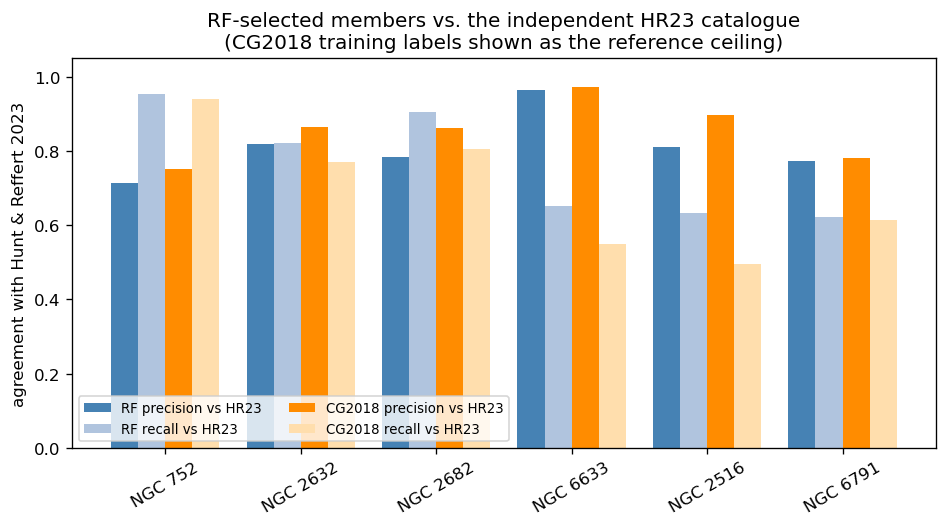

In [21]:
if len(cmp):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(cmp)); w = 0.2
    ax.bar(x-1.5*w, cmp['RF_prec_vs_HR23'], w, label='RF precision vs HR23', color='steelblue')
    ax.bar(x-0.5*w, cmp['RF_rec_vs_HR23'],  w, label='RF recall vs HR23',    color='lightsteelblue')
    ax.bar(x+0.5*w, cmp['CG_prec_vs_HR23'], w, label='CG2018 precision vs HR23', color='darkorange')
    ax.bar(x+1.5*w, cmp['CG_rec_vs_HR23'],  w, label='CG2018 recall vs HR23',    color='navajowhite')
    ax.set_xticks(x); ax.set_xticklabels([c.replace('_',' ') for c in cmp.index], rotation=30)
    ax.set_ylim(0, 1.05); ax.set_ylabel('agreement with Hunt & Reffert 2023')
    ax.set_title('RF-selected members vs. the independent HR23 catalogue\n(CG2018 training labels shown as the reference ceiling)')
    ax.legend(fontsize=8, ncol=2, loc='lower left')
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item2_hr23_agreement.png', dpi=150); plt.show()

### 4b. Digging into the HR23 disagreements

Three confounds can make agreement with HR23 look worse than the classifier really is, and each is testable:

* **Magnitude limit.** CG2018 labels stop at G = 18; HR23 goes to G ≈ 20. The RF never saw a labelled member fainter than G = 18, so HR23 members at G > 18 are unreachable by construction. Recall is therefore recomputed on G < 18 only.
* **Probability threshold.** HR23 probabilities are defined differently from CG2018's; the "new candidate" confirmation rate is shown at P ≥ 0.5, P ≥ 0.3 and "listed at any probability".
* **Where do the unconfirmed candidates sit?** If they lie on the cluster sequence in the CMD and in the PM clump, they are plausible members (halo / tidal-tail stars beyond the catalogues' radius); if they scatter, they are contamination and should be reported as such.

Finally, the catalogue members the RF *misses* are checked against their CG2018 probability — borderline labels (PMemb 0.5–0.7) are the expected failure mode.

In [24]:
G_LIM = 18.0
rows4b = []
for cl in CLUSTERS:
    if cl not in hr23: continue
    df = data[cl].copy(); df['rf_prob_oof'] = oof[cl]
    df['source_id'] = df['source_id'].astype(np.int64)
    hr = hr23[cl].set_index('source_id')['prob']
    df['hr_prob'] = df['source_id'].map(hr)          
    bright = df['phot_g_mean_mag'] < G_LIM
    rfm = df['rf_prob_oof'] >= 0.5; cat = df['member'] == 1; new = rfm & ~cat

    def recall(sel, thr):
        ref = (df['hr_prob'] >= thr) & sel
        return (ref & rfm).sum() / ref.sum() if ref.sum() else np.nan
    def cg_recall(sel, thr):
        ref = (df['hr_prob'] >= thr) & sel
        return (ref & cat).sum() / ref.sum() if ref.sum() else np.nan

    rows4b.append(dict(
        cluster=cl,
        RF_recall_HR23_all=recall(df['hr_prob'].notna(), 0.5),
        RF_recall_HR23_Glt18=recall(bright, 0.5),
        CG_recall_HR23_Glt18=cg_recall(bright, 0.5),
        HR23_members_Ggt18_frac=((df['hr_prob'] >= 0.5) & ~bright).sum() / max((df['hr_prob'] >= 0.5).sum(), 1),
        new_cands=int(new.sum()),
        new_in_HR23_p50=int((new & (df['hr_prob'] >= 0.5)).sum()),
        new_in_HR23_p30=int((new & (df['hr_prob'] >= 0.3)).sum()),
        new_in_HR23_any=int((new & df['hr_prob'].notna()).sum()),
    ))
    data[cl] = df  

t4b = pd.DataFrame(rows4b).set_index('cluster')
t4b['new_frac_p50'] = t4b.new_in_HR23_p50 / t4b.new_cands
t4b['new_frac_p30'] = t4b.new_in_HR23_p30 / t4b.new_cands
t4b['new_frac_any'] = t4b.new_in_HR23_any / t4b.new_cands
t4b.to_csv(f'{OUT_DIR}/item2b_hr23_confounds.csv')
t4b.round(3)

,RF_recall_HR23_all,RF_recall_HR23_Glt18,CG_recall_HR23_Glt18,HR23_members_Ggt18_frac,new_cands,new_in_HR23_p50,new_in_HR23_p30,new_in_HR23_any,new_frac_p50,new_frac_p30,new_frac_any
cluster,,,,,,,,,,,
NGC_752,0.954,0.989,0.974,0.036,32,5,26,32,0.156,0.812,1.000
NGC_2632,0.822,0.979,0.919,0.161,102,41,90,99,0.402,0.882,0.971
NGC_2682,0.903,0.980,0.872,0.078,201,85,189,199,0.423,0.940,0.990
NGC_6633,0.651,0.785,0.661,0.170,55,49,54,54,0.891,0.982,0.982
NGC_2516,0.634,0.923,0.723,0.314,396,229,374,386,0.578,0.944,0.975
NGC_6791,0.623,0.991,0.975,0.371,81,22,42,55,0.272,0.519,0.679


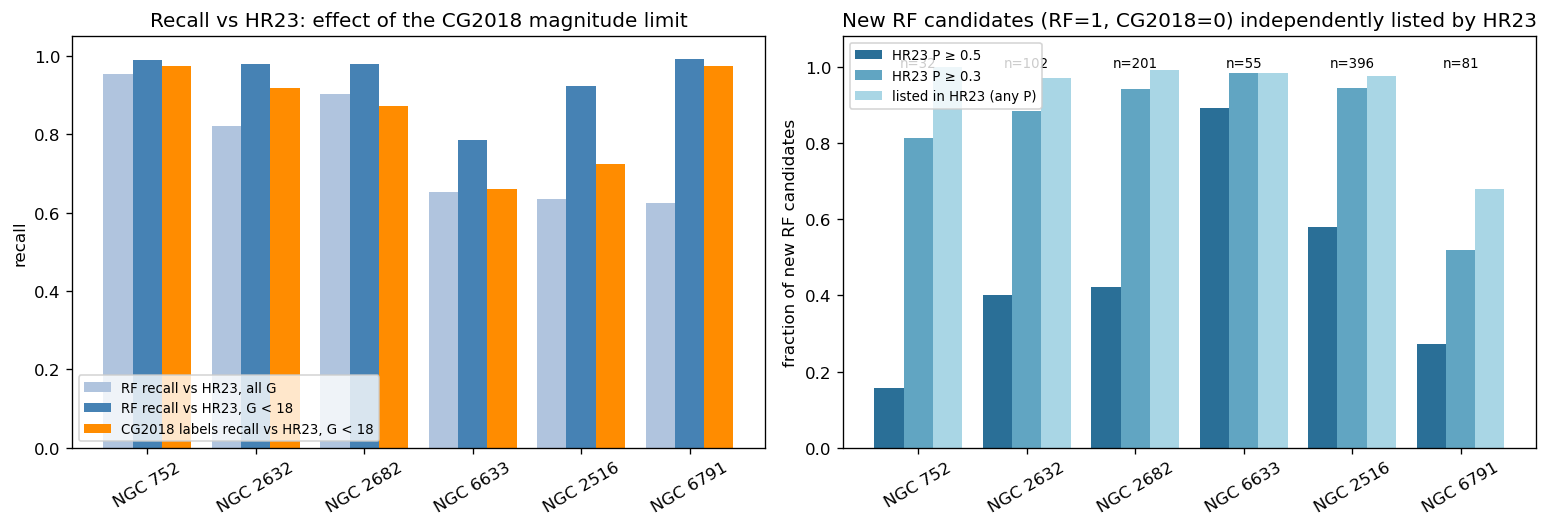

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(t4b)); w = 0.27
ax = axes[0]
ax.bar(x-w, t4b['RF_recall_HR23_all'],   w, color='lightsteelblue', label=f'RF recall vs HR23, all G')
ax.bar(x,   t4b['RF_recall_HR23_Glt18'], w, color='steelblue',      label=f'RF recall vs HR23, G < {G_LIM:.0f}')
ax.bar(x+w, t4b['CG_recall_HR23_Glt18'], w, color='darkorange',     label=f'CG2018 labels recall vs HR23, G < {G_LIM:.0f}')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_',' ') for c in t4b.index], rotation=30)
ax.set_ylim(0, 1.05); ax.set_ylabel('recall'); ax.legend(fontsize=8, loc='lower left')
ax.set_title('Recall vs HR23: effect of the CG2018 magnitude limit')

ax = axes[1]
ax.bar(x-w, t4b['new_frac_p50'], w, color='#2a6f97', label='HR23 P ≥ 0.5')
ax.bar(x,   t4b['new_frac_p30'], w, color='#61a5c2', label='HR23 P ≥ 0.3')
ax.bar(x+w, t4b['new_frac_any'], w, color='#a9d6e5', label='listed in HR23 (any P)')
for i, n in enumerate(t4b['new_cands']):
    ax.text(i, 1.0, f'n={n}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([c.replace('_',' ') for c in t4b.index], rotation=30)
ax.set_ylim(0, 1.08); ax.set_ylabel('fraction of new RF candidates'); ax.legend(fontsize=8, loc='upper left')
ax.set_title('New RF candidates (RF=1, CG2018=0) independently listed by HR23')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item2b_confounds.png', dpi=150); plt.show()

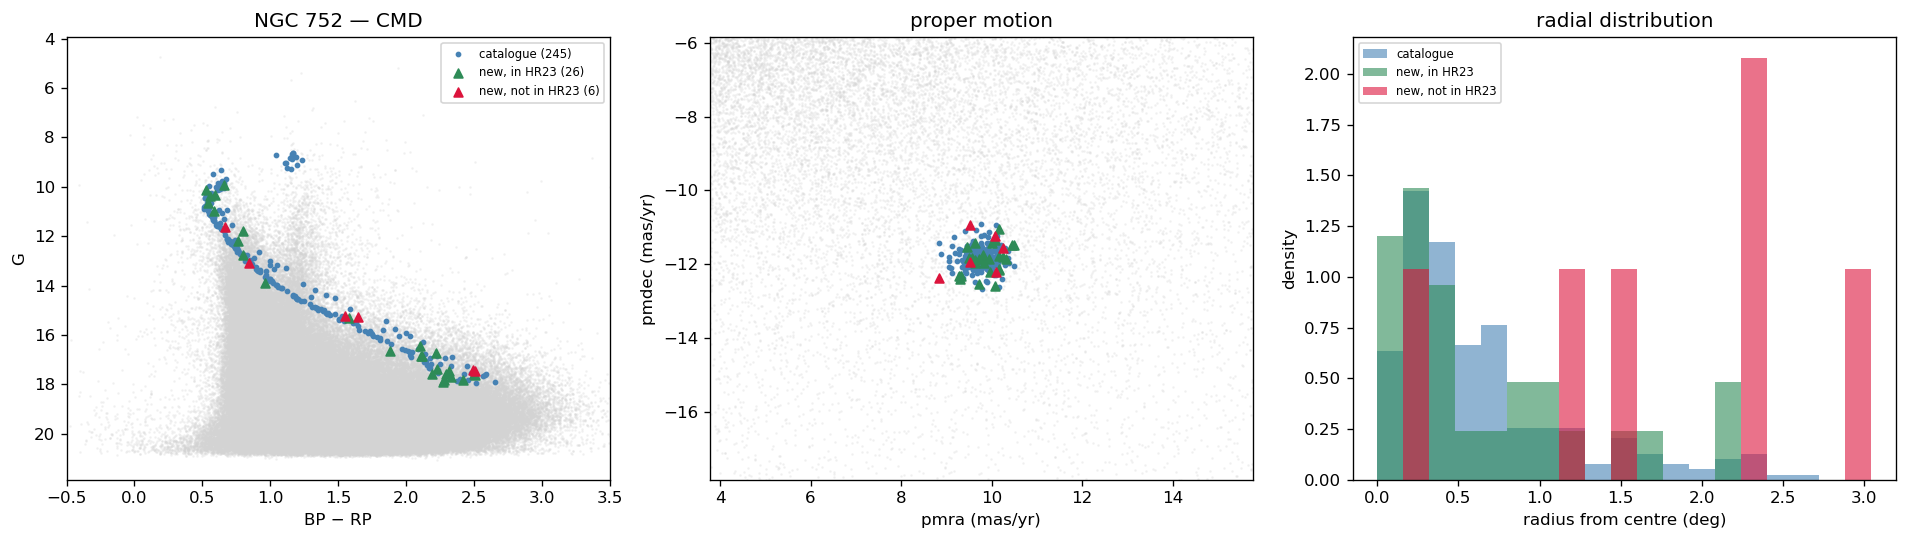

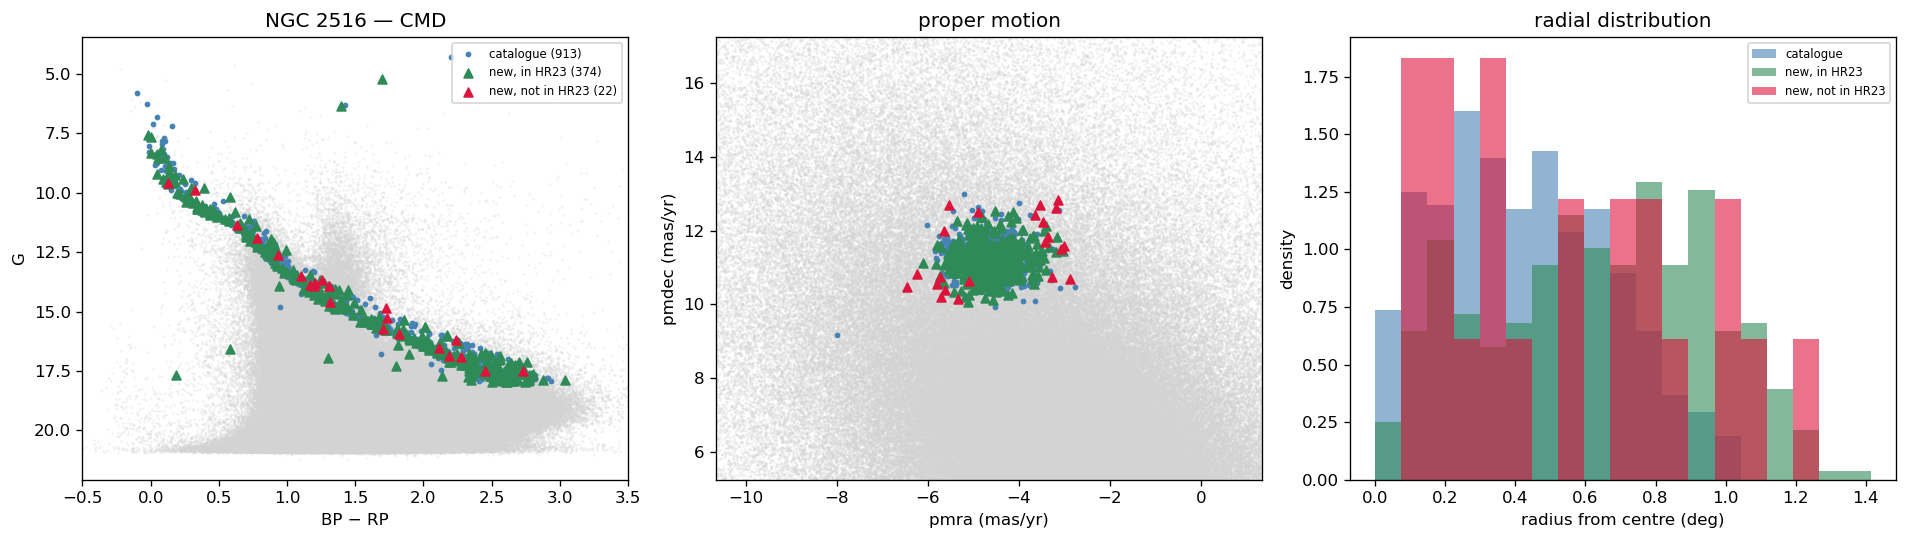

NGC 752: 6 new candidates not in HR23 (P>=0.3). Catalogue-member medians: plx=2.27, pmra=9.77, pmdec=-11.84


,source_id,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,rf_prob_oof,hr_prob,r_deg
82900,332298802194319488,2.276,9.524,-11.947,13.074,0.846,0.840,0.281,2.902
147575,343474410177401088,2.390,10.260,-11.551,17.469,2.507,0.815,0.298,2.298
102423,342824981057834368,2.442,10.107,-12.211,15.225,1.550,0.790,0.276,1.189
24911,319401569455164544,2.121,10.086,-11.223,17.420,2.492,0.785,0.234,2.284
49658,330874694117035648,2.324,8.837,-12.387,15.272,1.646,0.665,0.289,1.479
103899,342927678020018688,2.033,9.532,-10.936,11.635,0.663,0.565,0.264,0.167


In [28]:

def candidate_panels(cl, ax_cmd, ax_pm, ax_r):
    df = data[cl]; cat = df['member']==1; rfm = df['rf_prob_oof']>=0.5; new = rfm & ~cat
    conf = new & (df['hr_prob'] >= 0.3); unconf = new & ~(df['hr_prob'] >= 0.3)
    r = np.hypot(df['delta_ra'], df['delta_dec'])
    # CMD
    ax_cmd.scatter(df['bp_rp'], df['phot_g_mean_mag'], s=0.3, c='lightgrey', alpha=0.3, rasterized=True)
    ax_cmd.scatter(df.loc[cat,'bp_rp'], df.loc[cat,'phot_g_mean_mag'], s=6, c='steelblue', label=f'catalogue ({cat.sum()})')
    ax_cmd.scatter(df.loc[conf,'bp_rp'], df.loc[conf,'phot_g_mean_mag'], s=28, marker='^', c='seagreen', label=f'new, in HR23 ({conf.sum()})')
    ax_cmd.scatter(df.loc[unconf,'bp_rp'], df.loc[unconf,'phot_g_mean_mag'], s=28, marker='^', c='crimson', label=f'new, not in HR23 ({unconf.sum()})')
    ax_cmd.invert_yaxis(); ax_cmd.set_xlim(-0.5, 3.5); ax_cmd.set_xlabel('BP − RP'); ax_cmd.set_ylabel('G')
    ax_cmd.set_title(f'{cl.replace("_"," ")} — CMD'); ax_cmd.legend(fontsize=7)
    # PM
    c = df.loc[cat, ['pmra','pmdec']].median()
    ax_pm.scatter(df['pmra'], df['pmdec'], s=0.3, c='lightgrey', alpha=0.3, rasterized=True)
    ax_pm.scatter(df.loc[cat,'pmra'], df.loc[cat,'pmdec'], s=6, c='steelblue')
    ax_pm.scatter(df.loc[conf,'pmra'], df.loc[conf,'pmdec'], s=28, marker='^', c='seagreen')
    ax_pm.scatter(df.loc[unconf,'pmra'], df.loc[unconf,'pmdec'], s=28, marker='^', c='crimson')
    ax_pm.set_xlim(c.pmra-6, c.pmra+6); ax_pm.set_ylim(c.pmdec-6, c.pmdec+6)
    ax_pm.set_xlabel('pmra (mas/yr)'); ax_pm.set_ylabel('pmdec (mas/yr)'); ax_pm.set_title('proper motion')
    # radius histogram
    bins = np.linspace(0, r[rfm|cat].max()*1.05, 20)
    ax_r.hist(r[cat], bins, alpha=0.6, color='steelblue', label='catalogue', density=True)
    ax_r.hist(r[conf], bins, alpha=0.6, color='seagreen', label='new, in HR23', density=True)
    ax_r.hist(r[unconf], bins, alpha=0.6, color='crimson', label='new, not in HR23', density=True)
    ax_r.set_xlabel('radius from centre (deg)'); ax_r.set_ylabel('density'); ax_r.set_title('radial distribution'); ax_r.legend(fontsize=7)

for cl in ['NGC_752', 'NGC_2516']:
    if cl not in hr23: continue
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    candidate_panels(cl, *axes)
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item2b_{cl}_candidates.png', dpi=150); plt.show()


df = data['NGC_752']; new = (df['rf_prob_oof']>=0.5) & (df['member']==0) & ~(df['hr_prob']>=0.3)
print(f'NGC 752: {new.sum()} new candidates not in HR23 (P>=0.3). Catalogue-member medians: '
      f'plx={df.loc[df.member==1,"parallax"].median():.2f}, pmra={df.loc[df.member==1,"pmra"].median():.2f}, '
      f'pmdec={df.loc[df.member==1,"pmdec"].median():.2f}')
df.loc[new, ['source_id','parallax','pmra','pmdec','phot_g_mean_mag','bp_rp','rf_prob_oof','hr_prob']]\
  .assign(r_deg=np.hypot(df.loc[new,'delta_ra'], df.loc[new,'delta_dec'])).sort_values('rf_prob_oof', ascending=False).round(3)

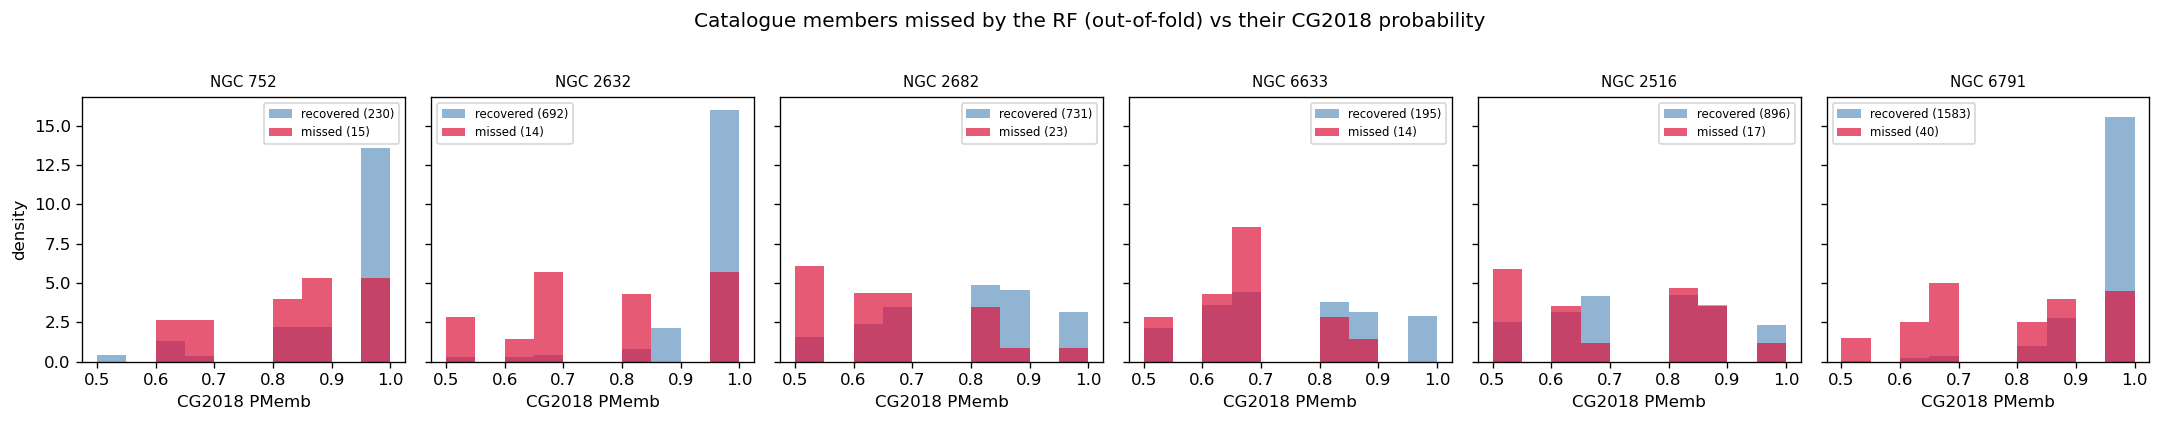

,n_missed,missed_median_PMemb,recovered_median_PMemb,missed_frac_PMemb_lt_0p7,missed_median_G,recovered_median_G
cluster,,,,,,
NGC_752,15,0.90,1.0,0.267,13.405000,13.053
NGC_2632,14,0.75,1.0,0.500,16.011000,15.111
NGC_2682,23,0.60,0.8,0.739,16.249001,14.595
NGC_6633,14,0.70,0.7,0.786,15.700000,13.780
NGC_2516,17,0.70,0.8,0.529,13.586000,15.021
NGC_6791,40,0.80,1.0,0.450,17.201000,17.348


In [30]:

fig, axes = plt.subplots(1, len(CLUSTERS), figsize=(3.0*len(CLUSTERS), 3.4), sharey=True)
miss_rows = []
for ax, cl in zip(axes, CLUSTERS):
    df = data[cl]; cat = df['member']==1; rfm = df['rf_prob_oof']>=0.5
    hit, miss = df.loc[cat & rfm, 'proba_cg'], df.loc[cat & ~rfm, 'proba_cg']
    bins = np.linspace(0.5, 1.0, 11)
    ax.hist(hit,  bins, alpha=0.6, color='steelblue', density=True, label=f'recovered ({len(hit)})')
    ax.hist(miss, bins, alpha=0.7, color='crimson',   density=True, label=f'missed ({len(miss)})')
    ax.set_title(cl.replace('_',' '), fontsize=9); ax.set_xlabel('CG2018 PMemb'); ax.legend(fontsize=7)
    miss_rows.append(dict(cluster=cl, n_missed=len(miss),
                          missed_median_PMemb=miss.median() if len(miss) else np.nan,
                          recovered_median_PMemb=hit.median(),
                          missed_frac_PMemb_lt_0p7=(miss < 0.7).mean() if len(miss) else np.nan,
                          missed_median_G=df.loc[cat & ~rfm, 'phot_g_mean_mag'].median() if len(miss) else np.nan,
                          recovered_median_G=df.loc[cat & rfm, 'phot_g_mean_mag'].median()))
axes[0].set_ylabel('density')
plt.suptitle('Catalogue members missed by the RF (out-of-fold) vs their CG2018 probability', y=1.02)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item4b_missed_members.png', dpi=150); plt.show()
missed = pd.DataFrame(miss_rows).set_index('cluster'); missed.to_csv(f'{OUT_DIR}/item4b_missed_members.csv')
missed.round(3)

## 5. Item 3 — Which features matter? (feature-subset ablation)

The Gini importances in the original report suggest that astrometry dominates, but Gini importance is known to be biased toward continuous, high-cardinality features and is split between correlated features (`pmra`, `pmdec`, `pm_mag`). The clean test is to **retrain with subsets** and see what performance survives. The same train/test split is used for every subset.

In [33]:
FEATURE_SETS = {
    'PM only'              : ['pmra', 'pmdec', 'pm_mag'],
    'parallax only'        : ['parallax'],
    'photometry only'      : ['phot_g_mean_mag', 'bp_rp', 'bp_g'],
    'position only'        : ['delta_ra', 'delta_dec'],
    'PM + parallax'        : ['pmra', 'pmdec', 'pm_mag', 'parallax'],
    'PM + parallax + pos'  : ['pmra', 'pmdec', 'pm_mag', 'parallax', 'delta_ra', 'delta_dec'],
    'PM + parallax + phot' : ['pmra', 'pmdec', 'pm_mag', 'parallax', 'phot_g_mean_mag', 'bp_rp', 'bp_g'],
    'all 9 features'       : FEATURES_ALL,
}

abl_rows = []
for cl in CLUSTERS:
    df = data[cl]
    for name, feats in FEATURE_SETS.items():
        _, m, _ = train_rf(df, df['member'], feats)
        abl_rows.append(dict(cluster=cl, feature_set=name, n_features=len(feats), **m))
abl = pd.DataFrame(abl_rows)
abl.to_csv(f'{OUT_DIR}/item3_feature_ablation.csv', index=False)

print('=== NGC 752 (reference cluster) ===')
display(abl[abl.cluster=='NGC_752'].set_index('feature_set')[['n_features','precision','recall','f1','AP','FP','FN']].round(3))
print('\n=== F1 across all clusters ===')
f1_table = abl.pivot(index='feature_set', columns='cluster', values='f1').loc[list(FEATURE_SETS)]
f1_table['mean'] = f1_table.mean(axis=1)
display(f1_table.round(3))

=== NGC 752 (reference cluster) ===


,n_features,precision,recall,f1,AP,FP,FN
feature_set,,,,,,,
PM only,3,0.532,0.857,0.656,0.622,37,7
parallax only,1,0.079,0.816,0.144,0.099,466,9
photometry only,3,0.035,0.612,0.066,0.100,834,19
position only,2,0.018,0.755,0.034,0.037,2066,12
PM + parallax,4,0.865,0.918,0.891,0.908,7,4
PM + parallax + pos,6,0.828,0.980,0.897,0.971,10,1
PM + parallax + phot,7,0.889,0.980,0.932,0.990,6,1
all 9 features,9,0.889,0.980,0.932,0.988,6,1



=== F1 across all clusters ===


cluster,NGC_2516,NGC_2632,NGC_2682,NGC_6633,NGC_6791,NGC_752,mean
feature_set,,,,,,,
PM only,0.157,0.738,0.633,0.027,0.516,0.656,0.455
parallax only,0.247,0.660,0.512,0.047,0.058,0.144,0.278
photometry only,0.106,0.477,0.475,0.020,0.206,0.066,0.225
position only,0.037,0.043,0.355,0.003,0.282,0.034,0.126
PM + parallax,0.458,0.789,0.749,0.672,0.554,0.891,0.685
PM + parallax + pos,0.604,0.802,0.808,0.788,0.609,0.897,0.751
PM + parallax + phot,0.661,0.878,0.833,0.796,0.881,0.932,0.830
all 9 features,0.833,0.899,0.911,0.882,0.958,0.932,0.902


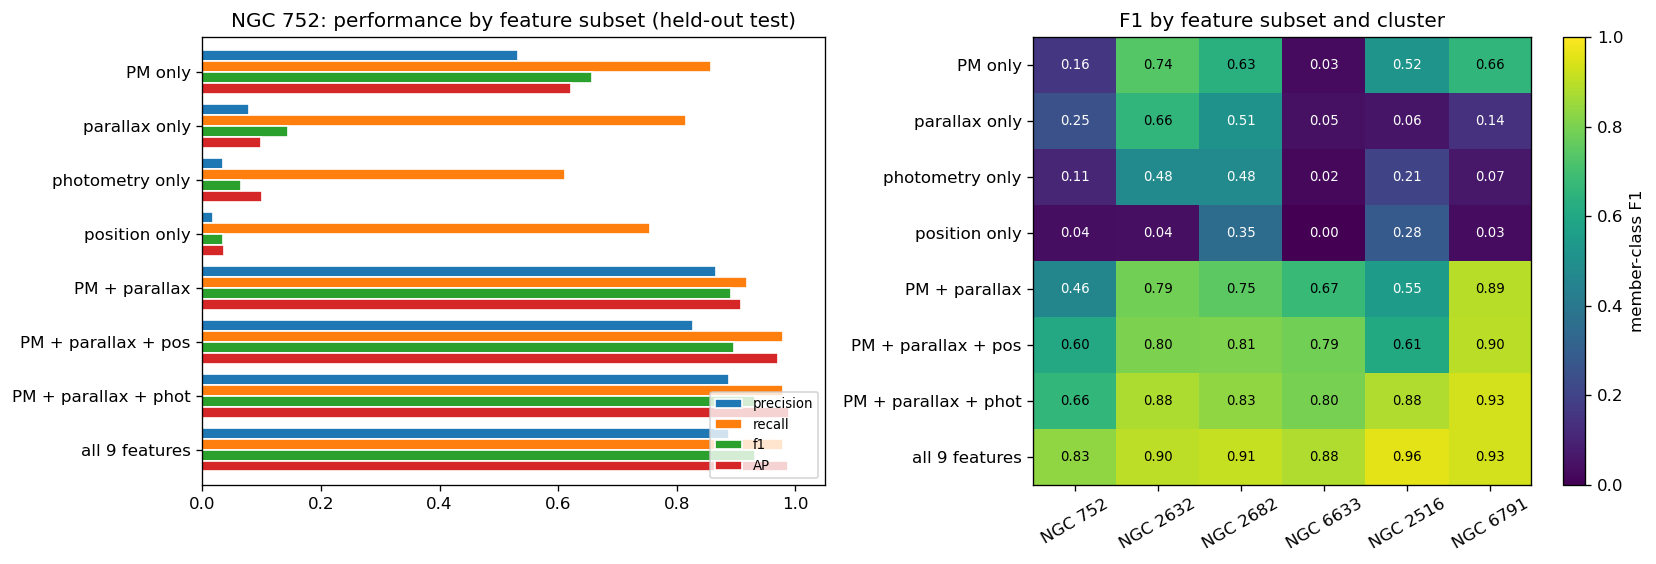

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
sub = abl[abl.cluster=='NGC_752'].set_index('feature_set').loc[list(FEATURE_SETS)]
sub[['precision','recall','f1','AP']].plot(kind='barh', ax=ax, width=0.8, edgecolor='white')
ax.set_xlim(0, 1.05); ax.set_ylabel(''); ax.set_title('NGC 752: performance by feature subset (held-out test)')
ax.legend(fontsize=8, loc='lower right'); ax.invert_yaxis()

ax = axes[1]
im = ax.imshow(f1_table.drop(columns='mean').values, vmin=0, vmax=1, cmap='viridis', aspect='auto')
ax.set_yticks(range(len(f1_table))); ax.set_yticklabels(f1_table.index)
ax.set_xticks(range(len(CLUSTERS))); ax.set_xticklabels([c.replace('_',' ') for c in CLUSTERS], rotation=30)
for i in range(f1_table.shape[0]):
    for j in range(len(CLUSTERS)):
        v = f1_table.iloc[i, j]; ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                                          color='white' if v < 0.6 else 'black')
plt.colorbar(im, ax=ax, label='member-class F1'); ax.set_title('F1 by feature subset and cluster')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item3_ablation.png', dpi=150); plt.show()

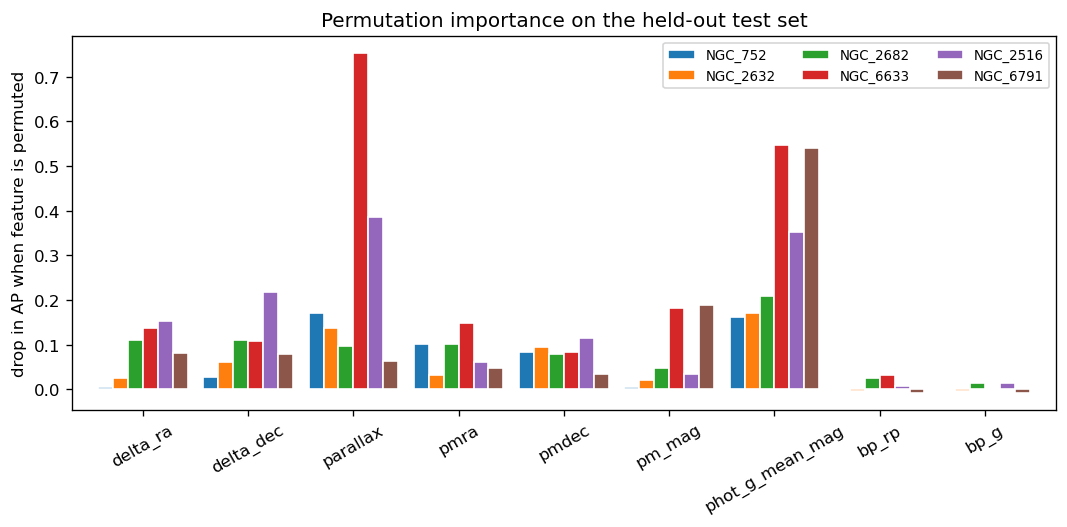

,delta_ra,delta_dec,parallax,pmra,pmdec,pm_mag,phot_g_mean_mag,bp_rp,bp_g
NGC_752,0.005,0.028,0.172,0.102,0.083,0.006,0.161,0.001,0.002
NGC_2632,0.025,0.061,0.138,0.032,0.096,0.021,0.171,-0.003,-0.004
NGC_2682,0.110,0.110,0.096,0.102,0.080,0.047,0.209,0.025,0.014
NGC_6633,0.137,0.108,0.753,0.148,0.083,0.182,0.548,0.032,0.002
NGC_2516,0.154,0.219,0.385,0.061,0.116,0.035,0.353,0.008,0.014
NGC_6791,0.081,0.079,0.063,0.048,0.034,0.189,0.540,-0.007,-0.009


In [37]:

perm_rows = []
for cl in CLUSTERS:
    df = data[cl]
    rf, _, (Xtr, Xte, ytr, yte) = train_rf(df, df['member'], FEATURES_ALL)
    pi = permutation_importance(rf, Xte, yte, scoring='average_precision',
                                n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
    perm_rows.append(pd.Series(pi.importances_mean, index=FEATURES_ALL, name=cl))
perm = pd.DataFrame(perm_rows)
perm.to_csv(f'{OUT_DIR}/item3_permutation_importance.csv')

fig, ax = plt.subplots(figsize=(9, 4.5))
perm.T.plot(kind='bar', ax=ax, width=0.85, edgecolor='white')
ax.set_ylabel('drop in AP when feature is permuted'); ax.set_xlabel('')
ax.set_title('Permutation importance on the held-out test set'); ax.legend(fontsize=8, ncol=3)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item3_permutation_importance.png', dpi=150); plt.show()
perm.round(3)

## 6. Item 4 — Catalogue members vs. RF-classified members (explicit bookkeeping)

Three distinct numbers were sometimes conflated in the report. They are separated here, per cluster:

* **Catalogue members** — CG2018 stars with PMemb ≥ 0.5 that fall in our cone and survive the NaN cut. These are the *training labels*, not a result of this work.
* **Held-out test members** — the 20 % of labelled members the model never saw (the numbers quoted in the abstract, e.g. 47/49 for NGC 752).
* **RF-classified members** — stars with out-of-fold P(member) ≥ 0.5 over the *whole* cone. Because every star is scored by a model that did not train on it, this is the honest "membership list" the RF produces. It splits into (a) catalogue members recovered and (b) **new candidates** with no CG2018 label.

Scoring the full sample with the model that was trained on 80 % of it (as the original CMD/PM figures did) is *in-sample* for 80 % of the stars and inflates agreement; it should not be quoted as a result.

In [40]:
book_rows = []
for cl in CLUSTERS:
    df = data[cl].copy()
    df['rf_prob_oof'] = oof[cl]
    df['rf_member']   = (df['rf_prob_oof'] >= 0.5).astype(int)
    cat = df['member'] == 1; rfm = df['rf_member'] == 1
    insample = models[cl].predict_proba(df[FEATURES_ALL])[:,1] >= 0.5
    book_rows.append(dict(
        cluster=cl,
        stars_in_cone=len(df),
        catalogue_members_CG2018=int(cat.sum()),
        test_members_heldout=int(multi.loc[cl,'n_test_members']),
        test_members_recovered=int(multi.loc[cl,'TP']),
        RF_members_OOF=int(rfm.sum()),
        RF_recovered_catalogue=int((cat & rfm).sum()),
        RF_missed_catalogue=int((cat & ~rfm).sum()),
        RF_new_candidates=int((~cat & rfm).sum()),
        RF_members_INSAMPLE_do_not_quote=int(insample.sum()),
    ))
    
    cols = ['source_id','ra','dec','parallax','pmra','pmdec','phot_g_mean_mag','bp_rp',
            'proba_cg','member','rf_prob_oof','rf_member']
    df.loc[rfm | cat, cols].sort_values('rf_prob_oof', ascending=False)\
      .to_csv(f'{OUT_DIR}/{cl}_membership_table.csv', index=False)

book = pd.DataFrame(book_rows).set_index('cluster')
book.to_csv(f'{OUT_DIR}/item4_bookkeeping.csv')
book

,stars_in_cone,catalogue_members_CG2018,test_members_heldout,test_members_recovered,RF_members_OOF,RF_recovered_catalogue,RF_missed_catalogue,RF_new_candidates,RF_members_INSAMPLE_do_not_quote
cluster,,,,,,,,,
NGC_752,194494,245,49,48,262,230,15,32,277
NGC_2632,113841,706,141,138,794,692,14,102,805
NGC_2682,14791,754,151,148,932,731,23,201,946
NGC_6633,1525454,209,42,41,250,195,14,55,256
NGC_2516,598093,913,183,182,1292,896,17,396,1306
NGC_6791,158471,1623,325,318,1664,1583,40,81,1694


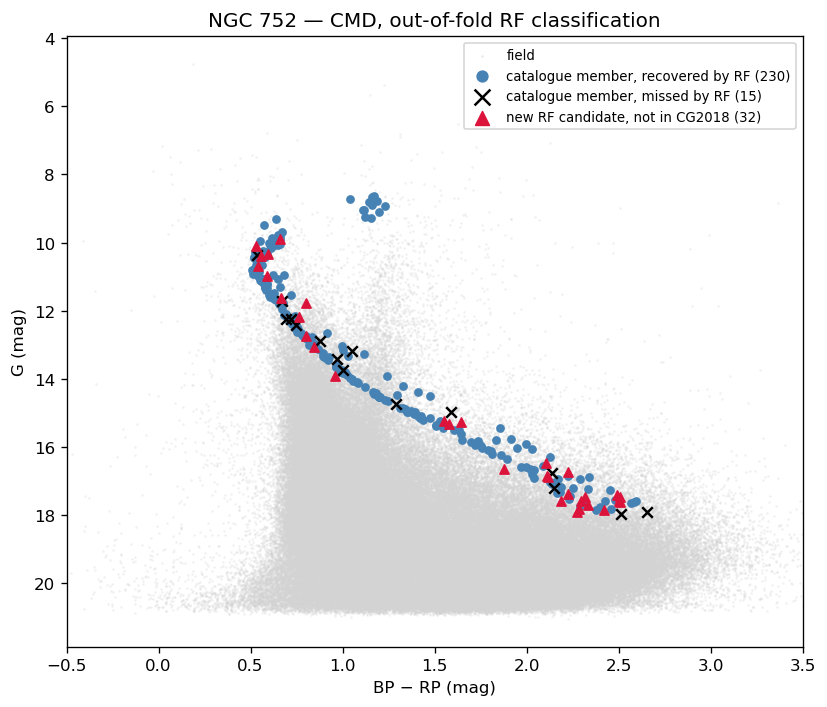

New RF candidates for NGC 752 (n=32); median parallax 2.24 mas vs catalogue members 2.27 mas


,source_id,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,rf_prob_oof
102057,342920501130956928,2.219,10.006,-11.428,13.903000,0.959,1.000
120822,342916339306367872,2.278,9.973,-12.209,9.910000,0.657,1.000
88568,342531789410540544,2.153,9.460,-11.522,16.724001,2.223,0.995
119661,342854324275209344,2.368,9.567,-11.844,10.115000,0.529,0.990
88582,342536290536098176,2.347,9.332,-12.323,10.387000,0.554,0.985
148338,343438916566722688,2.345,10.072,-11.344,16.864000,2.111,0.975
74604,330935171553194368,2.268,9.623,-11.875,17.580999,2.501,0.975
128950,343048452500144768,2.182,9.727,-11.869,17.590000,2.296,0.970
59347,330599923585568640,2.256,9.288,-12.314,10.992000,0.588,0.960
101839,342890569502955136,2.112,9.627,-11.956,17.603001,2.507,0.955


In [42]:

cl = 'NGC_752'; df = data[cl].copy(); df['rf_prob_oof'] = oof[cl]
cat = df['member']==1; rfm = df['rf_prob_oof']>=0.5
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['bp_rp'], df['phot_g_mean_mag'], s=0.3, c='lightgrey', alpha=0.3, rasterized=True, label='field')
ax.scatter(df.loc[cat & rfm,'bp_rp'], df.loc[cat & rfm,'phot_g_mean_mag'], s=18, c='steelblue',
           label=f'catalogue member, recovered by RF ({int((cat&rfm).sum())})')
ax.scatter(df.loc[cat & ~rfm,'bp_rp'], df.loc[cat & ~rfm,'phot_g_mean_mag'], s=40, marker='x', c='black',
           label=f'catalogue member, missed by RF ({int((cat&~rfm).sum())})')
ax.scatter(df.loc[~cat & rfm,'bp_rp'], df.loc[~cat & rfm,'phot_g_mean_mag'], s=30, marker='^', c='crimson',
           label=f'new RF candidate, not in CG2018 ({int((~cat&rfm).sum())})')
ax.invert_yaxis(); ax.set_xlim(-0.5, 3.5); ax.set_xlabel('BP − RP (mag)'); ax.set_ylabel('G (mag)')
ax.set_title('NGC 752 — CMD, out-of-fold RF classification'); ax.legend(fontsize=8, markerscale=1.5)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item4_ngc752_cmd_oof.png', dpi=150); plt.show()


new = df.loc[~cat & rfm, ['source_id','parallax','pmra','pmdec','phot_g_mean_mag','bp_rp','rf_prob_oof']]
print(f'New RF candidates for NGC 752 (n={len(new)}); median parallax {new.parallax.median():.2f} mas '
      f'vs catalogue members {df.loc[cat,"parallax"].median():.2f} mas')
new.sort_values('rf_prob_oof', ascending=False).head(15).round(3)

## 7. Robustness checks 

### 7.1 Sensitivity to the RF probability threshold

Out-of-fold probabilities are fixed; only the decision threshold varies (0.3, 0.5, 0.7, 0.9). Metrics are computed against the CG2018 labels; the member count is what the published membership list would contain at each threshold.

In [45]:
THRESHOLDS = [0.3, 0.5, 0.7, 0.9]
thr_rows = []
for cl in CLUSTERS:
    df = data[cl]; y = df['member'].values; p = df['rf_prob_oof'].values
    for t in THRESHOLDS:
        yhat = (p >= t).astype(int)
        thr_rows.append(dict(cluster=cl, threshold=t,
                             n_selected=int(yhat.sum()),
                             new_candidates=int(((yhat==1)&(y==0)).sum()),
                             precision=precision_score(y, yhat, zero_division=0),
                             recall=recall_score(y, yhat, zero_division=0),
                             f1=f1_score(y, yhat, zero_division=0)))
thr = pd.DataFrame(thr_rows)
thr.to_csv(f'{OUT_DIR}/item5_threshold_sensitivity.csv', index=False)
display(thr.pivot(index='threshold', columns='cluster', values='f1').round(3))
thr[thr.cluster=='NGC_752'].set_index('threshold').round(3)

cluster,NGC_2516,NGC_2632,NGC_2682,NGC_6633,NGC_6791,NGC_752
threshold,,,,,,
0.3,0.741,0.913,0.837,0.790,0.938,0.898
0.5,0.813,0.923,0.867,0.850,0.963,0.907
0.7,0.823,0.925,0.871,0.860,0.962,0.908
0.9,0.828,0.920,0.879,0.834,0.956,0.913


,cluster,n_selected,new_candidates,precision,recall,f1
threshold,,,,,,
0.3,NGC_752,276,42,0.848,0.955,0.898
0.5,NGC_752,262,32,0.878,0.939,0.907
0.7,NGC_752,244,22,0.910,0.906,0.908
0.9,NGC_752,226,11,0.951,0.878,0.913


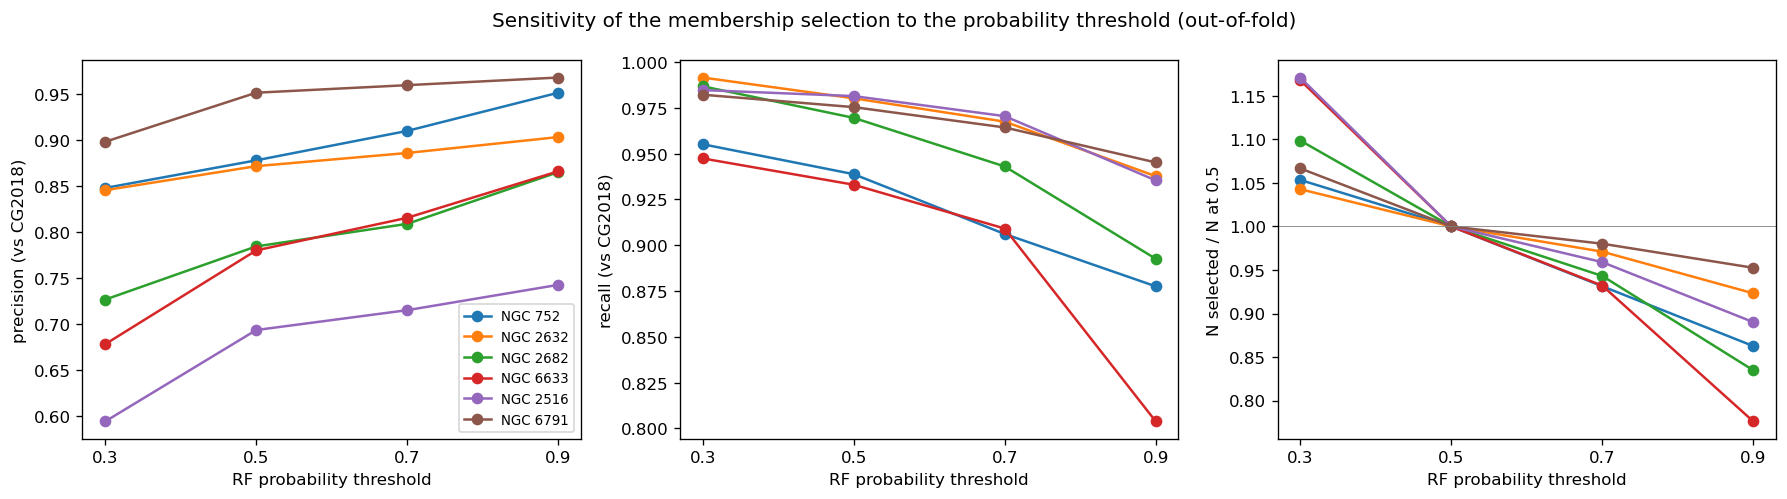

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for cl in CLUSTERS:
    sub = thr[thr.cluster==cl]
    axes[0].plot(sub.threshold, sub.precision, 'o-', label=cl.replace('_',' '))
    axes[1].plot(sub.threshold, sub.recall,    'o-')
    axes[2].plot(sub.threshold, sub.n_selected/sub.n_selected.iloc[1], 'o-')
axes[0].set_ylabel('precision (vs CG2018)'); axes[1].set_ylabel('recall (vs CG2018)')
axes[2].set_ylabel('N selected / N at 0.5'); axes[2].axhline(1, color='grey', lw=0.5)
for ax in axes: ax.set_xlabel('RF probability threshold'); ax.set_xticks(THRESHOLDS)
axes[0].legend(fontsize=8)
plt.suptitle('Sensitivity of the membership selection to the probability threshold (out-of-fold)')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item5_threshold_sensitivity.png', dpi=150); plt.show()

### 7.2 Astrometric-quality cut

Standard Gaia quality criterion RUWE < 1.4 (well-behaved single-star astrometric solutions). RUWE and parallax_over_error are fetched in a supplementary query (the original cone queries did not include them) and merged on `source_id`. The full pipeline is re-run on the cleaned sample; the question is whether the results, particularly for NGC 6791 and its agreement with HR23, are stable.

In [50]:
def query_quality(ra0, dec0, radius):
    q = ("SELECT source_id, ruwe, parallax_over_error "
         "FROM gaiadr3.gaia_source "
         "WHERE CONTAINS(POINT('ICRS', ra, dec), "
         f"CIRCLE('ICRS', {ra0}, {dec0}, {radius})) = 1 "
         "AND parallax > 0")
    return Gaia.launch_job_async(q).get_results().to_pandas()

qual_rows = []
for cl in CLUSTERS:
    info = cl_info.loc[cl]
    qc = f'{OUT_DIR}/{cl}_quality.parquet'
    if os.path.exists(qc):
        qdf = pd.read_parquet(qc)
    else:
        qdf = query_quality(info.ra0, info.dec0, info.radius_deg); qdf.to_parquet(qc)
    df = data[cl].merge(qdf, on='source_id', how='left')
    good = df['ruwe'] < 1.4
    dfg = df[good].reset_index(drop=True)

    _, m_clean, _ = train_rf(dfg, dfg['member'], FEATURES_ALL)
    p_oof_clean = oof_probabilities(dfg, dfg['member'], FEATURES_ALL)
    row = dict(cluster=cl, frac_removed=1-good.mean(),
               members_removed=int((df['member']==1).sum() - (dfg['member']==1).sum()),
               f1_before=multi.loc[cl,'f1'], f1_after=m_clean['f1'],
               prec_before=multi.loc[cl,'precision'], prec_after=m_clean['precision'],
               AP_before=multi.loc[cl,'AP'], AP_after=m_clean['AP'])
    if cl in hr23:
        sid = dfg['source_id'].astype(np.int64)
        hr50 = set(hr23[cl].loc[hr23[cl]['prob']>=0.5, 'source_id'])
        hr30 = set(hr23[cl].loc[hr23[cl]['prob']>=0.3, 'source_id'])
        rf_ids = set(sid[p_oof_clean>=0.5])
        bright = dfg['phot_g_mean_mag'] < G_LIM
        hrb = set(sid[bright & sid.isin(hr50)])
        row['RF_rec_HR23_Glt18_after'] = len(rf_ids & hrb)/len(hrb) if hrb else np.nan
        row['RF_rec_HR23_Glt18_before'] = t4b.loc[cl, 'RF_recall_HR23_Glt18'] if cl in t4b.index else np.nan
        newc = rf_ids - set(sid[dfg['member']==1])
        row['new_cands_after'] = len(newc); row['new_in_HR23_p30_after'] = len(newc & hr30)
    qual_rows.append(row)
    print(f'{cl:10s} removed {row["frac_removed"]:.1%} of stars ({row["members_removed"]} labelled members) '
          f'| F1 {row["f1_before"]:.2f}->{row["f1_after"]:.2f}  prec {row["prec_before"]:.2f}->{row["prec_after"]:.2f}')

qual = pd.DataFrame(qual_rows).set_index('cluster')
qual.to_csv(f'{OUT_DIR}/item6_quality_cut.csv')
qual.round(3)

INFO: Query finished. [astroquery.utils.tap.core]
NGC_752    removed 3.0% of stars (20 labelled members) | F1 0.93->0.95  prec 0.89->0.93
INFO: Query finished. [astroquery.utils.tap.core]
NGC_2632   removed 3.5% of stars (83 labelled members) | F1 0.90->0.97  prec 0.83->0.96
INFO: Query finished. [astroquery.utils.tap.core]
NGC_2682   removed 3.4% of stars (22 labelled members) | F1 0.91->0.86  prec 0.85->0.78
500 Error 500:
null


HTTPError: Error 500:
null

In [52]:
import time as _time

def _launch(q, tries=3, wait=45):
    for i in range(tries):
        try:
            return Gaia.launch_job_async(q).get_results().to_pandas()
        except Exception as e:
            if i == tries - 1:
                raise
            print(f'    archive error ({e}); retry {i+1}/{tries-1} in {wait}s')
            _time.sleep(wait)

def query_quality(ra0, dec0, radius):
    def cone_q(rin, rout):
        inner = ("AND CONTAINS(POINT('ICRS', ra, dec), "
                 f"CIRCLE('ICRS', {ra0}, {dec0}, {rin})) = 0 " if rin > 0 else "")
        return ("SELECT source_id, ruwe, parallax_over_error "
                "FROM gaiadr3.gaia_source "
                "WHERE CONTAINS(POINT('ICRS', ra, dec), "
                f"CIRCLE('ICRS', {ra0}, {dec0}, {rout})) = 1 "
                + inner + "AND parallax > 0")
    if radius <= 1.5:
        return _launch(cone_q(0, radius))
    
    edges = [0, 1.5, 2.25, radius]
    parts = []
    for rin, rout in zip(edges[:-1], edges[1:]):
        print(f'    quality sub-query: {rin}-{rout} deg')
        parts.append(_launch(cone_q(rin, rout)))
    return pd.concat(parts, ignore_index=True).drop_duplicates('source_id')

In [54]:
import time as _time

def _launch(q, tries=3, wait=45):
    for i in range(tries):
        try:
            return Gaia.launch_job_async(q).get_results().to_pandas()
        except Exception as e:
            if i == tries - 1:
                raise
            print(f'    archive error ({e}); retry {i+1}/{tries-1} in {wait}s')
            _time.sleep(wait)

def query_quality(ra0, dec0, radius):
    def cone_q(rin, rout):
        inner = ("AND CONTAINS(POINT('ICRS', ra, dec), "
                 f"CIRCLE('ICRS', {ra0}, {dec0}, {rin})) = 0 " if rin > 0 else "")
        return ("SELECT source_id, ruwe, parallax_over_error "
                "FROM gaiadr3.gaia_source "
                "WHERE CONTAINS(POINT('ICRS', ra, dec), "
                f"CIRCLE('ICRS', {ra0}, {dec0}, {rout})) = 1 "
                + inner + "AND parallax > 0")
    if radius <= 1.5:
        return _launch(cone_q(0, radius))
    edges = [0, 1.5, 2.25, radius]
    parts = []
    for rin, rout in zip(edges[:-1], edges[1:]):
        print(f'    quality sub-query: {rin}-{rout} deg')
        parts.append(_launch(cone_q(rin, rout)))
    return pd.concat(parts, ignore_index=True).drop_duplicates('source_id')

OOF_QUALITY_CLUSTERS = ['NGC_6791']   
qual_rows = []
for cl in CLUSTERS:
    info = cl_info.loc[cl]
    qc = f'{OUT_DIR}/{cl}_quality.parquet'
    if os.path.exists(qc):
        qdf = pd.read_parquet(qc)
    else:
        qdf = query_quality(info.ra0, info.dec0, info.radius_deg); qdf.to_parquet(qc)
    df = data[cl].merge(qdf, on='source_id', how='left')
    good = df['ruwe'] < 1.4
    dfg = df[good].reset_index(drop=True)

    _, m_clean, _ = train_rf(dfg, dfg['member'], FEATURES_ALL)
    row = dict(cluster=cl, frac_removed=1-good.mean(),
               members_removed=int((df['member']==1).sum() - (dfg['member']==1).sum()),
               f1_before=multi.loc[cl,'f1'], f1_after=m_clean['f1'],
               prec_before=multi.loc[cl,'precision'], prec_after=m_clean['precision'],
               AP_before=multi.loc[cl,'AP'], AP_after=m_clean['AP'])
    if cl in hr23 and cl in OOF_QUALITY_CLUSTERS:
        p_oof_clean = oof_probabilities(dfg, dfg['member'], FEATURES_ALL)
        sid = dfg['source_id'].astype(np.int64)
        hr50 = set(hr23[cl].loc[hr23[cl]['prob']>=0.5, 'source_id'])
        hr30 = set(hr23[cl].loc[hr23[cl]['prob']>=0.3, 'source_id'])
        rf_ids = set(sid[p_oof_clean>=0.5])
        bright = dfg['phot_g_mean_mag'] < G_LIM
        hrb = set(sid[bright & sid.isin(hr50)])
        row['RF_rec_HR23_Glt18_after'] = len(rf_ids & hrb)/len(hrb) if hrb else np.nan
        row['RF_rec_HR23_Glt18_before'] = t4b.loc[cl, 'RF_recall_HR23_Glt18'] if cl in t4b.index else np.nan
        newc = rf_ids - set(sid[dfg['member']==1])
        row['new_cands_after'] = len(newc); row['new_in_HR23_p30_after'] = len(newc & hr30)
    qual_rows.append(row)
    print(f'{cl:10s} removed {row["frac_removed"]:.1%} of stars ({row["members_removed"]} labelled members) '
          f'| F1 {row["f1_before"]:.2f}->{row["f1_after"]:.2f}  prec {row["prec_before"]:.2f}->{row["prec_after"]:.2f}')

qual = pd.DataFrame(qual_rows).set_index('cluster')
qual.to_csv(f'{OUT_DIR}/item6_quality_cut.csv')
qual.round(3)

NGC_752    removed 3.0% of stars (20 labelled members) | F1 0.93->0.95  prec 0.89->0.93
NGC_2632   removed 3.5% of stars (83 labelled members) | F1 0.90->0.97  prec 0.83->0.96
NGC_2682   removed 3.4% of stars (22 labelled members) | F1 0.91->0.86  prec 0.85->0.78
    quality sub-query: 0-1.5 deg
500 Error 500:
null
    archive error (Error 500:
null); retry 1/2 in 45s


KeyboardInterrupt: 

In [57]:
import time as _time
from astropy.table import Table

def quality_by_ids(source_ids, chunk=50000, tries=3, wait=45):
    """Fetch ruwe/parallax_over_error for exactly the stars we have, via upload+join."""
    ids = np.asarray(source_ids, dtype=np.int64)
    parts = []
    for i in range(0, len(ids), chunk):
        t = Table({'source_id': ids[i:i+chunk]})
        q = ("SELECT g.source_id, g.ruwe, g.parallax_over_error "
             "FROM gaiadr3.gaia_source AS g "
             "JOIN tap_upload.ids AS u ON g.source_id = u.source_id")
        for k in range(tries):
            try:
                job = Gaia.launch_job_async(q, upload_resource=t, upload_table_name='ids')
                parts.append(job.get_results().to_pandas())
                break
            except Exception as e:
                if k == tries - 1: raise
                print(f'    archive error ({e}); retry {k+1}/{tries-1} in {wait}s')
                _time.sleep(wait)
        print(f'    fetched {min(i+chunk, len(ids)):,} / {len(ids):,}')
    return pd.concat(parts, ignore_index=True)

OOF_QUALITY_CLUSTERS = ['NGC_6791']
qual_rows = []
for cl in CLUSTERS:
    qc = f'{OUT_DIR}/{cl}_quality.parquet'
    if os.path.exists(qc):
        qdf = pd.read_parquet(qc)
    else:
        print(f'{cl}: fetching quality columns by source_id upload...')
        qdf = quality_by_ids(data[cl]['source_id'].values)
        qdf.to_parquet(qc)
    df = data[cl].merge(qdf, on='source_id', how='left')
    good = df['ruwe'] < 1.4
    dfg = df[good].reset_index(drop=True)

    _, m_clean, _ = train_rf(dfg, dfg['member'], FEATURES_ALL)
    row = dict(cluster=cl, frac_removed=1-good.mean(),
               members_removed=int((df['member']==1).sum() - (dfg['member']==1).sum()),
               f1_before=multi.loc[cl,'f1'], f1_after=m_clean['f1'],
               prec_before=multi.loc[cl,'precision'], prec_after=m_clean['precision'],
               AP_before=multi.loc[cl,'AP'], AP_after=m_clean['AP'])
    if cl in hr23 and cl in OOF_QUALITY_CLUSTERS:
        p_oof_clean = oof_probabilities(dfg, dfg['member'], FEATURES_ALL)
        sid = dfg['source_id'].astype(np.int64)
        hr50 = set(hr23[cl].loc[hr23[cl]['prob']>=0.5, 'source_id'])
        hr30 = set(hr23[cl].loc[hr23[cl]['prob']>=0.3, 'source_id'])
        rf_ids = set(sid[p_oof_clean>=0.5])
        bright = dfg['phot_g_mean_mag'] < G_LIM
        hrb = set(sid[bright & sid.isin(hr50)])
        row['RF_rec_HR23_Glt18_after'] = len(rf_ids & hrb)/len(hrb) if hrb else np.nan
        row['RF_rec_HR23_Glt18_before'] = t4b.loc[cl, 'RF_recall_HR23_Glt18'] if cl in t4b.index else np.nan
        newc = rf_ids - set(sid[dfg['member']==1])
        row['new_cands_after'] = len(newc); row['new_in_HR23_p30_after'] = len(newc & hr30)
    qual_rows.append(row)
    print(f'{cl:10s} removed {row["frac_removed"]:.1%} of stars ({row["members_removed"]} labelled members) '
          f'| F1 {row["f1_before"]:.2f}->{row["f1_after"]:.2f}  prec {row["prec_before"]:.2f}->{row["prec_after"]:.2f}')

qual = pd.DataFrame(qual_rows).set_index('cluster')
qual.to_csv(f'{OUT_DIR}/item6_quality_cut.csv')
qual.round(3)

NGC_752    removed 3.0% of stars (20 labelled members) | F1 0.93->0.95  prec 0.89->0.93
NGC_2632   removed 3.5% of stars (83 labelled members) | F1 0.90->0.97  prec 0.83->0.96
NGC_2682   removed 3.4% of stars (22 labelled members) | F1 0.91->0.86  prec 0.85->0.78
NGC_6633: fetching quality columns by source_id upload...
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 50,000 / 1,525,454
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 100,000 / 1,525,454
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 150,000 / 1,525,454
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 200,000 / 1,525,454
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 250,000 / 1,525,454
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 300,000 / 1,525,454
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 350,000 / 1,525,454
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 400,000 / 1,525,454
INFO: Query finished. [

,frac_removed,members_removed,f1_before,f1_after,prec_before,prec_after,AP_before,AP_after,RF_rec_HR23_Glt18_after,RF_rec_HR23_Glt18_before,new_cands_after,new_in_HR23_p30_after
cluster,,,,,,,,,,,,
NGC_752,0.030,20,0.932,0.945,0.889,0.935,0.988,0.991,NaN,NaN,NaN,NaN
NGC_2632,0.035,83,0.899,0.972,0.831,0.961,0.929,0.992,NaN,NaN,NaN,NaN
NGC_2682,0.034,22,0.911,0.863,0.851,0.776,0.932,0.954,NaN,NaN,NaN,NaN
NGC_6633,0.022,15,0.882,0.940,0.804,0.886,0.886,0.952,NaN,NaN,NaN,NaN
NGC_2516,0.028,64,0.833,0.853,0.717,0.758,0.823,0.898,NaN,NaN,NaN,NaN
NGC_6791,0.026,14,0.958,0.969,0.938,0.963,0.968,0.972,0.991,0.991,67.0,41.0


### 7.3 Canonical bookkeeping check

The 47/49 in the course report came from the earlier 0.5-arcsec cross-match run; the extended pipeline (1-arcsec match) is the version of record.

In [60]:
cl = 'NGC_752'; df = data[cl]
y = df['member'].values; p = df['rf_prob_oof'].values
Xtr, Xte, ytr, yte = train_test_split(df[FEATURES_ALL], df['member'], test_size=0.2,
                                      random_state=RANDOM_STATE, stratify=df['member'])
rf = RandomForestClassifier(**RF_KW).fit(Xtr, ytr)
yhat_te = rf.predict(Xte)
print('CANONICAL NUMBERS — NGC 752 (version of record: 1-arcsec match, this notebook)')
print(f'  stars in cone after cleaning ............ {len(df):,}')
print(f'  catalogue (CG2018) members .............. {int(y.sum())}')
print(f'  held-out test members ................... {int(yte.sum())}')
print(f'  held-out test members recovered ......... {int(((yhat_te==1)&(yte==1)).sum())}')
print(f'  held-out false positives ................ {int(((yhat_te==1)&(yte==0)).sum())}')
print(f'  OOF RF members (P>=0.5) ................. {int((p>=0.5).sum())}')
print(f'     catalogue members recovered .......... {int(((p>=0.5)&(y==1)).sum())}')
print(f'     catalogue members missed ............. {int(((p<0.5)&(y==1)).sum())}')
print(f'     new candidates ....................... {int(((p>=0.5)&(y==0)).sum())}')
print()
print('Use ONLY these numbers in the manuscript. The 47/49, F1=0.90, 8-FP values from the')
print('course report belong to the earlier 0.5-arcsec run and must not be mixed in.')

CANONICAL NUMBERS — NGC 752 (version of record: 1-arcsec match, this notebook)
  stars in cone after cleaning ............ 194,494
  catalogue (CG2018) members .............. 245
  held-out test members ................... 49
  held-out test members recovered ......... 48
  held-out false positives ................ 6
  OOF RF members (P>=0.5) ................. 262
     catalogue members recovered .......... 230
     catalogue members missed ............. 15
     new candidates ....................... 32

Use ONLY these numbers in the manuscript. The 47/49, F1=0.90, 8-FP values from the
course report belong to the earlier 0.5-arcsec run and must not be mixed in.


## 7. Summary 


In [63]:
print('='*72); print('  SUMMARY'); print('='*72)
print('\nItem 1 — same RF configuration, trained and tested separately on each cluster:')
for cl, r in multi.iterrows():
    print(f'  {cl:10s} d={r.dist_pc:>5.0f} pc  labelled={r.n_label1:>4}  '
          f'F1={r.f1:.2f}  AP={r.AP:.2f}  prec={r.precision:.2f}  rec={r.recall:.2f}')
print(f'  mean F1 = {multi.f1.mean():.2f}  (min {multi.f1.min():.2f}, max {multi.f1.max():.2f})')

if len(cmp):
    print('\nItem 2 — agreement with Hunt & Reffert 2023 (independent DR3 catalogue):')
    for cl, r in cmp.iterrows():
        print(f'  {cl:10s} RF prec/rec vs HR23 = {r.RF_prec_vs_HR23:.2f}/{r.RF_rec_vs_HR23:.2f}   '
              f'CG2018 labels vs HR23 = {r.CG_prec_vs_HR23:.2f}/{r.CG_rec_vs_HR23:.2f}   '
              f'new RF cands confirmed by HR23: {r.new_cand_in_HR23}/{r.new_RF_candidates}')

if len(t4b):
    print('\nItem 2b — after removing the magnitude-limit confound (G < 18) and relaxing HR23 threshold:')
    for cl, r in t4b.iterrows():
        print(f'  {cl:10s} RF recall vs HR23 all-G {r.RF_recall_HR23_all:.2f} -> G<18 {r.RF_recall_HR23_Glt18:.2f} '
              f'(CG labels G<18: {r.CG_recall_HR23_Glt18:.2f}) | new cands in HR23: '
              f'{r.new_frac_p50:.0%} (P>=0.5)  {r.new_frac_p30:.0%} (P>=0.3)  {r.new_frac_any:.0%} (any)')

print('\nItem 3 — feature ablation (mean F1 over clusters):')
for fs, v in f1_table['mean'].items():
    print(f'  {fs:22s} {v:.2f}')

print('\nItem 5 — threshold sensitivity (F1 at 0.3/0.5/0.7/0.9):')
for cl in CLUSTERS:
    sub = thr[thr.cluster==cl]
    print(f'  {cl:10s} ' + '  '.join(f'{t:.1f}:{f:.2f}' for t, f in zip(sub.threshold, sub.f1)))

print('\nItem 6 — RUWE<1.4 quality cut:')
for cl, r in qual.iterrows():
    extra = ''
    if pd.notna(r.get('RF_rec_HR23_Glt18_after', np.nan)):
        extra = f'  HR23 G<18 recall {r.RF_rec_HR23_Glt18_before:.2f}->{r.RF_rec_HR23_Glt18_after:.2f}'
    print(f'  {cl:10s} F1 {r.f1_before:.2f}->{r.f1_after:.2f}  prec {r.prec_before:.2f}->{r.prec_after:.2f}{extra}')

print('\nItem 4 — bookkeeping (NGC 752):')
b = book.loc['NGC_752']
print(f'  catalogue (CG2018) members in cone ....... {b.catalogue_members_CG2018}')
print(f'  held-out test members / recovered ........ {b.test_members_heldout} / {b.test_members_recovered}')
print(f'  RF-classified members (out-of-fold) ...... {b.RF_members_OOF}')
print(f'     = {b.RF_recovered_catalogue} catalogue members + {b.RF_new_candidates} new candidates '
      f'({b.RF_missed_catalogue} catalogue members missed)')

print('\nSuggested wording for the validation/generalisation statements:')
print('  "The classifier was trained and evaluated independently on six clusters spanning 0.2–4 kpc.')
print('   Held-out performance and agreement with an independent catalogue indicate that the approach')
print('   is not specific to NGC 752, although per-cluster training on published labels is still')
print('   required; we have not tested transfer of a model trained on one cluster to another."')
print(f'\nAll tables and figures written to ./{OUT_DIR}/')

  SUMMARY

Item 1 — same RF configuration, trained and tested separately on each cluster:
  NGC_752    d=  441 pc  labelled=245.0  F1=0.93  AP=0.99  prec=0.89  rec=0.98
  NGC_2632   d=  186 pc  labelled=706.0  F1=0.90  AP=0.93  prec=0.83  rec=0.98
  NGC_2682   d=  859 pc  labelled=754.0  F1=0.91  AP=0.93  prec=0.85  rec=0.98
  NGC_6633   d=  392 pc  labelled=209.0  F1=0.88  AP=0.89  prec=0.80  rec=0.98
  NGC_2516   d=  409 pc  labelled=913.0  F1=0.83  AP=0.82  prec=0.72  rec=0.99
  NGC_6791   d= 4531 pc  labelled=1623.0  F1=0.96  AP=0.97  prec=0.94  rec=0.98
  mean F1 = 0.90  (min 0.83, max 0.96)

Item 2 — agreement with Hunt & Reffert 2023 (independent DR3 catalogue):
  NGC_752    RF prec/rec vs HR23 = 0.71/0.95   CG2018 labels vs HR23 = 0.75/0.94   new RF cands confirmed by HR23: 5.0/32.0
  NGC_2632   RF prec/rec vs HR23 = 0.82/0.82   CG2018 labels vs HR23 = 0.86/0.77   new RF cands confirmed by HR23: 41.0/102.0
  NGC_2682   RF prec/rec vs HR23 = 0.78/0.90   CG2018 labels vs HR23 = 0

In [67]:

 
PM_RA_COL = _col(cg_clusters, ['pmRA', 'pmra'])
PM_DE_COL = _col(cg_clusters, ['pmDE', 'pmdec'])
PLX_COL   = _col(cg_clusters, ['plx', 'parallax'])
cl_ref = cg_clusters.set_index('Cluster').loc[CLUSTERS, [PM_RA_COL, PM_DE_COL, PLX_COL]]
cl_ref.columns = ['pm_ra0', 'pm_de0', 'plx0']
cl_ref['d_pc'] = cl_info['dist_pc']
display(cl_ref)
 
K_VT = 4.74047   # km/s per (mas/yr * kpc)
def add_physical(df, cl):
    r = cl_ref.loc[cl]; d_kpc = r.d_pc / 1000.0
    df = df.copy()
    df['dv_ra']     = K_VT * (df['pmra']  - r.pm_ra0) * d_kpc     # km/s tangential offset
    df['dv_dec']    = K_VT * (df['pmdec'] - r.pm_de0) * d_kpc
    df['dv']        = np.hypot(df['dv_ra'], df['dv_dec'])
    df['dplx_frac'] = (df['parallax'] - r.plx0) / r.plx0            # fractional distance offset
    df['MG']        = df['phot_g_mean_mag'] - 5*np.log10(r.d_pc) + 5 # abs mag AT CLUSTER DISTANCE
    df['r_pc']      = np.hypot(df['delta_ra'], df['delta_dec']) * np.pi/180 * r.d_pc
    return df
 
for cl in CLUSTERS:
    data[cl] = add_physical(data[cl], cl)
 
FEATURES_PHYS      = ['dv_ra', 'dv_dec', 'dv', 'dplx_frac', 'MG', 'bp_rp', 'bp_g']
FEATURES_PHYS_POS  = FEATURES_PHYS + ['r_pc']
FEATURES_NOPOS     = ['parallax', 'pmra', 'pmdec', 'pm_mag', 'phot_g_mean_mag', 'bp_rp', 'bp_g']
print('physical features added')

,pm_ra0,pm_de0,plx0,d_pc
Cluster,,,,
NGC_752,9.810,-11.713,2.239,441.000000
NGC_2632,-36.090,-12.919,5.361,185.500000
NGC_2682,-10.986,-2.964,1.135,859.099976
NGC_6633,1.198,-1.811,2.525,391.600006
NGC_2516,-4.748,11.221,2.417,408.899994
NGC_6791,-0.421,-2.269,0.192,4530.799805


physical features added


[physical, no position ] hold out NGC_752  : F1=0.59 P=0.42 R=1.00 AP=0.89 (within-cluster F1 0.93)  10s
[physical, no position ] hold out NGC_2632 : F1=0.75 P=0.84 R=0.68 AP=0.82 (within-cluster F1 0.90)  10s
[physical, no position ] hold out NGC_2682 : F1=0.63 P=0.46 R=1.00 AP=0.70 (within-cluster F1 0.91)  12s
[physical, no position ] hold out NGC_6633 : F1=0.27 P=0.15 R=1.00 AP=0.65 (within-cluster F1 0.88)  11s
[physical, no position ] hold out NGC_2516 : F1=0.36 P=0.22 R=1.00 AP=0.48 (within-cluster F1 0.83)  11s
[physical, no position ] hold out NGC_6791 : F1=0.47 P=0.75 R=0.34 AP=0.62 (within-cluster F1 0.96)  10s
[physical + r_pc       ] hold out NGC_752  : F1=0.66 P=0.51 R=0.93 AP=0.84 (within-cluster F1 0.93)  11s
[physical + r_pc       ] hold out NGC_2632 : F1=0.76 P=0.84 R=0.69 AP=0.84 (within-cluster F1 0.90)  11s
[physical + r_pc       ] hold out NGC_2682 : F1=0.63 P=0.46 R=1.00 AP=0.87 (within-cluster F1 0.91)  13s
[physical + r_pc       ] hold out NGC_6633 : F1=0.29 P=

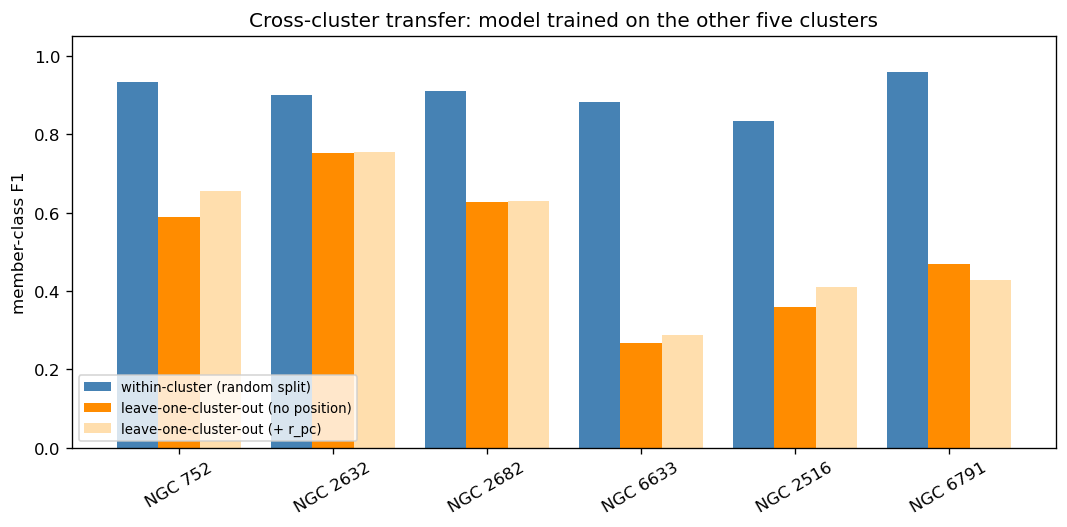

In [69]:

 
N_NEG_PER_CLUSTER = 100_000
rng = np.random.default_rng(RANDOM_STATE)
 
def training_pool(exclude, features):
    parts = []
    for cl in CLUSTERS:
        if cl == exclude: continue
        df = data[cl]
        mem = df[df['member'] == 1]
        non = df[df['member'] == 0]
        non = non.sample(min(N_NEG_PER_CLUSTER, len(non)), random_state=RANDOM_STATE)
        parts.append(pd.concat([mem, non])[features + ['member']])
    return pd.concat(parts, ignore_index=True)
 
loco_rows = []; loco_prob = {}
for fs_name, feats in [('physical, no position', FEATURES_PHYS), ('physical + r_pc', FEATURES_PHYS_POS)]:
    for target in CLUSTERS:
        t0 = time.time()
        pool = training_pool(target, feats)
        rf = RandomForestClassifier(**RF_KW).fit(pool[feats], pool['member'])
        df = data[target]
        prob = rf.predict_proba(df[feats])[:, 1]
        m = evaluate(df['member'], (prob >= 0.5).astype(int), prob)
        row = dict(feature_set=fs_name, target=target, within_cluster_f1=multi.loc[target, 'f1'], **m)
        if target in hr23:
            hr50 = set(hr23[target].loc[hr23[target]['prob'] >= 0.5, 'source_id'])
            hr30 = set(hr23[target].loc[hr23[target]['prob'] >= 0.3, 'source_id'])
            sid = df['source_id'].astype(np.int64)
            bright = df['phot_g_mean_mag'] < G_LIM
            hrb = set(sid[bright & sid.isin(hr50)])
            rf_ids = set(sid[prob >= 0.5])
            row['HR23_recall_Glt18'] = len(rf_ids & hrb) / len(hrb) if hrb else np.nan
            newc = rf_ids - set(sid[df['member'] == 1])
            row['new_cands'] = len(newc); row['new_in_HR23_p30'] = len(newc & hr30) / len(newc) if newc else np.nan
        loco_rows.append(row)
        if fs_name.startswith('physical, no'): loco_prob[target] = prob
        print(f'[{fs_name:22s}] hold out {target:9s}: F1={m["f1"]:.2f} P={m["precision"]:.2f} R={m["recall"]:.2f} AP={m["AP"]:.2f} '
              f'(within-cluster F1 {multi.loc[target,"f1"]:.2f})  {time.time()-t0:.0f}s')
 
loco = pd.DataFrame(loco_rows)
loco.to_csv(f'{OUT_DIR}/item8_1_loco.csv', index=False)
loco.pivot(index='target', columns='feature_set', values='f1').assign(within_cluster=multi['f1']).round(3)
 
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CLUSTERS)); w = 0.27
sub0 = loco[loco.feature_set == 'physical, no position'].set_index('target').loc[CLUSTERS]
sub1 = loco[loco.feature_set == 'physical + r_pc'].set_index('target').loc[CLUSTERS]
ax.bar(x - w, multi.loc[CLUSTERS, 'f1'], w, color='steelblue',      label='within-cluster (random split)')
ax.bar(x,     sub0['f1'],                w, color='darkorange',     label='leave-one-cluster-out (no position)')
ax.bar(x + w, sub1['f1'],                w, color='navajowhite',    label='leave-one-cluster-out (+ r_pc)')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_', ' ') for c in CLUSTERS], rotation=30)
ax.set_ylim(0, 1.05); ax.set_ylabel('member-class F1'); ax.legend(fontsize=8, loc='lower left')
ax.set_title('Cross-cluster transfer: model trained on the other five clusters')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_1_loco.png', dpi=150); plt.show()
 

In [91]:


def errors_by_ids(source_ids, cluster, chunk=50000, tries=4, wait=60):
    ids = np.asarray(source_ids, dtype=np.int64)
    cdir = f'{OUT_DIR}/{cluster}_echunks'; os.makedirs(cdir, exist_ok=True)
    parts = []
    for i in range(0, len(ids), chunk):
        cf = f'{cdir}/chunk_{i}.parquet'
        if os.path.exists(cf):
            parts.append(pd.read_parquet(cf)); continue
        t = Table({'source_id': ids[i:i+chunk]})
        q = ("SELECT g.source_id, g.pmra_error, g.pmdec_error, g.parallax_error "
             "FROM gaiadr3.gaia_source AS g JOIN tap_upload.ids AS u ON g.source_id = u.source_id")
        for k in range(tries):
            try:
                part = Gaia.launch_job_async(q, upload_resource=t, upload_table_name='ids').get_results().to_pandas()
                part.to_parquet(cf); parts.append(part); break
            except Exception as e:
                if k == tries - 1: raise
                print(f'    archive error; retry {k+1}/{tries-1} in {wait}s'); time.sleep(wait)
        print(f'    fetched {min(i+chunk, len(ids)):,} / {len(ids):,}')
    return pd.concat(parts, ignore_index=True)


for cl in CLUSTERS:
    ec = f'{OUT_DIR}/{cl}_errors.parquet'
    if os.path.exists(ec):
        edf = pd.read_parquet(ec)
    else:
        print(f'{cl}: fetching astrometric errors...')
        edf = errors_by_ids(data[cl]['source_id'].values, cl); edf.to_parquet(ec)
    df = data[cl]
    if 'pmra_error' not in df.columns:
        df = df.merge(edf, on='source_id', how='left')
    r = cl_ref.loc[cl]
    df['dmu_ra_sig'] = (df['pmra']  - r.pm_ra0) / df['pmra_error']
    df['dmu_de_sig'] = (df['pmdec'] - r.pm_de0) / df['pmdec_error']
    df['dmu_sig']    = np.hypot(df['dmu_ra_sig'], df['dmu_de_sig'])
    df['dplx_sig']   = (df['parallax'] - r.plx0) / df['parallax_error']
    data[cl] = df.dropna(subset=['dmu_sig', 'dplx_sig']).reset_index(drop=True)

FEATURES_PHYS_SIG = ['dv_ra', 'dv_dec', 'dv', 'dplx_frac',
                     'dmu_ra_sig', 'dmu_de_sig', 'dmu_sig', 'dplx_sig',
                     'MG', 'bp_rp', 'bp_g']

def loco_v2(feats, label):
    rows = []; probs = {}
    for target in CLUSTERS:
        t0 = time.time()
        pool = training_pool(target, feats)
        Ptr, Pva, ytr, yva = train_test_split(pool[feats], pool['member'], test_size=0.2,
                                              random_state=RANDOM_STATE, stratify=pool['member'])
        rf = RandomForestClassifier(**RF_KW).fit(Ptr, ytr)
        pva = rf.predict_proba(Pva)[:, 1]
        # threshold chosen on the TRAINING clusters' validation split only
        thr = max(((f1_score(yva, (pva >= t).astype(int), zero_division=0), t)
                   for t in np.arange(0.30, 0.995, 0.01)))[1]
        df = data[target]; p = rf.predict_proba(df[feats])[:, 1]
        m = evaluate(df['member'], (p >= thr).astype(int), p)
        row = dict(feature_set=label, target=target, threshold=thr,
                   within_cluster_f1=multi.loc[target, 'f1'], **m)
        if target in hr23:
            hr50 = set(hr23[target].loc[hr23[target]['prob'] >= 0.5, 'source_id'])
            hr30 = set(hr23[target].loc[hr23[target]['prob'] >= 0.3, 'source_id'])
            sid = df['source_id'].astype(np.int64); bright = df['phot_g_mean_mag'] < G_LIM
            hrb = set(sid[bright & sid.isin(hr50)]); rf_ids = set(sid[p >= thr])
            row['HR23_recall_Glt18'] = len(rf_ids & hrb) / len(hrb) if hrb else np.nan
            newc = rf_ids - set(sid[df['member'] == 1])
            row['new_cands'] = len(newc); row['new_in_HR23_p30'] = len(newc & hr30) / len(newc) if newc else np.nan
        rows.append(row); probs[target] = p
        print(f'[{label:14s}] {target:9s} thr={thr:.2f}  F1={m["f1"]:.2f} P={m["precision"]:.2f} R={m["recall"]:.2f} '
              f'AP={m["AP"]:.2f}  (within {multi.loc[target,"f1"]:.2f})  {time.time()-t0:.0f}s')
    return pd.DataFrame(rows), probs

loco_a, _        = loco_v2(FEATURES_PHYS,     'phys')          # v1 features, proper threshold
loco_b, loco_p2  = loco_v2(FEATURES_PHYS_SIG, 'phys + sigma')  # + uncertainty-normalised
loco2 = pd.concat([loco_a, loco_b]); loco2.to_csv(f'{OUT_DIR}/item8_1b_loco_v2.csv', index=False)
display(loco2.pivot(index='target', columns='feature_set', values=['f1', 'AP', 'threshold']).round(3))

fig, ax = plt.subplots(figsize=(9, 4.5)); x = np.arange(len(CLUSTERS)); w = 0.27
ax.bar(x - w, multi.loc[CLUSTERS, 'f1'], w, color='steelblue', label='within-cluster (random split)')
ax.bar(x,     loco_a.set_index('target').loc[CLUSTERS, 'f1'], w, color='navajowhite', label='LOCO, physical features')
ax.bar(x + w, loco_b.set_index('target').loc[CLUSTERS, 'f1'], w, color='darkorange',  label='LOCO, + uncertainty-normalised')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_', ' ') for c in CLUSTERS], rotation=30)
ax.set_ylim(0, 1.05); ax.set_ylabel('member-class F1'); ax.legend(fontsize=8, loc='lower left', frameon=False)
ax.set_title('Cross-cluster transfer (threshold chosen on training clusters only)')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_1b_loco_v2.png', dpi=200); plt.show()

NGC_752: fetching astrometric errors...
    archive error; retry 1/3 in 60s
    archive error; retry 2/3 in 60s
    archive error; retry 3/3 in 60s


RemoteDisconnected: Remote end closed connection without response

[phys  ] NGC_752   thr=0.85  F1=0.80 P=0.67 R=1.00 AP=0.90  (within 0.93)  9s
[phys  ] NGC_2632  thr=0.88  F1=0.74 P=0.90 R=0.63 AP=0.83  (within 0.90)  8s
[phys  ] NGC_2682  thr=0.90  F1=0.73 P=0.59 R=0.96 AP=0.71  (within 0.91)  10s
[phys  ] NGC_6633  thr=0.94  F1=0.60 P=0.43 R=0.99 AP=0.65  (within 0.88)  10s
[phys  ] NGC_2516  thr=0.93  F1=0.50 P=0.33 R=0.98 AP=0.47  (within 0.83)  8s
[phys  ] NGC_6791  thr=0.91  F1=0.28 P=0.82 R=0.17 AP=0.61  (within 0.96)  8s


,threshold,precision,recall,f1,AP,within_cluster_f1,HR23_recall_Glt18,new_in_HR23_p30
target,,,,,,,,
NGC_752,0.85,0.673,1.000,0.805,0.895,0.932,1.000,0.471
NGC_2632,0.88,0.897,0.630,0.740,0.827,0.899,0.640,0.804
NGC_2682,0.90,0.594,0.963,0.734,0.711,0.911,0.989,0.855
NGC_6633,0.94,0.432,0.990,0.602,0.652,0.882,0.987,0.713
NGC_2516,0.93,0.334,0.977,0.498,0.470,0.833,0.988,0.889
NGC_6791,0.91,0.821,0.172,0.284,0.610,0.958,0.191,0.689


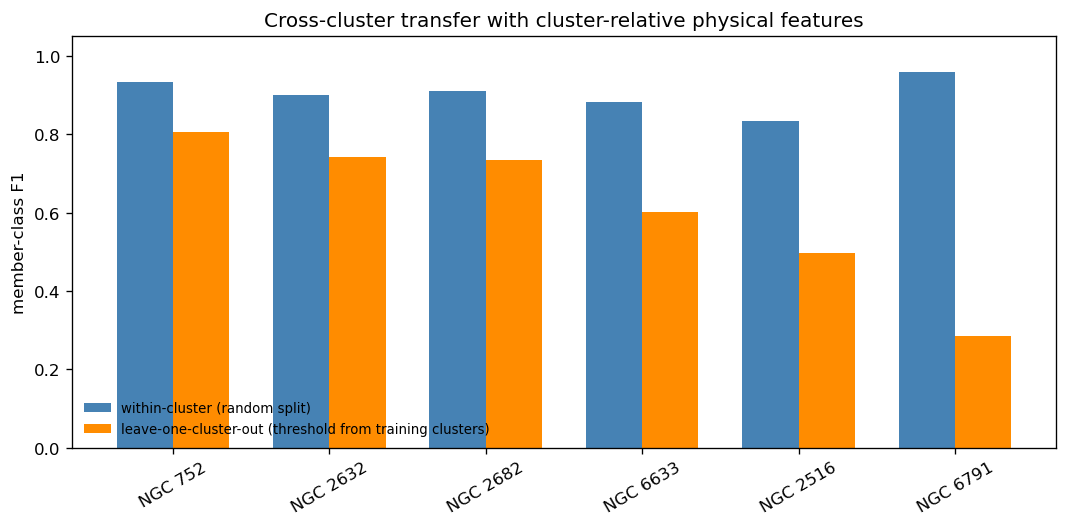

In [95]:

def loco_v2(feats, label):
    rows = []; probs = {}
    for target in CLUSTERS:
        t0 = time.time()
        pool = training_pool(target, feats)
        Ptr, Pva, ytr, yva = train_test_split(pool[feats], pool['member'], test_size=0.2,
                                              random_state=RANDOM_STATE, stratify=pool['member'])
        rf = RandomForestClassifier(**RF_KW).fit(Ptr, ytr)
        pva = rf.predict_proba(Pva)[:, 1]
        thr = max(((f1_score(yva, (pva >= t).astype(int), zero_division=0), t)
                   for t in np.arange(0.30, 0.995, 0.01)))[1]      # chosen WITHOUT the target
        df = data[target]; p = rf.predict_proba(df[feats])[:, 1]
        m = evaluate(df['member'], (p >= thr).astype(int), p)
        row = dict(feature_set=label, target=target, threshold=thr,
                   within_cluster_f1=multi.loc[target, 'f1'], **m)
        if target in hr23:
            hr50 = set(hr23[target].loc[hr23[target]['prob'] >= 0.5, 'source_id'])
            hr30 = set(hr23[target].loc[hr23[target]['prob'] >= 0.3, 'source_id'])
            sid = df['source_id'].astype(np.int64); bright = df['phot_g_mean_mag'] < G_LIM
            hrb = set(sid[bright & sid.isin(hr50)]); rf_ids = set(sid[p >= thr])
            row['HR23_recall_Glt18'] = len(rf_ids & hrb) / len(hrb) if hrb else np.nan
            newc = rf_ids - set(sid[df['member'] == 1])
            row['new_cands'] = len(newc)
            row['new_in_HR23_p30'] = len(newc & hr30) / len(newc) if newc else np.nan
        rows.append(row); probs[target] = p
        print(f'[{label:6s}] {target:9s} thr={thr:.2f}  F1={m["f1"]:.2f} P={m["precision"]:.2f} '
              f'R={m["recall"]:.2f} AP={m["AP"]:.2f}  (within {multi.loc[target,"f1"]:.2f})  {time.time()-t0:.0f}s')
    return pd.DataFrame(rows), probs

loco_a, loco_pa = loco_v2(FEATURES_PHYS, 'phys')
loco_a.to_csv(f'{OUT_DIR}/item8_1b_loco_v2.csv', index=False)
display(loco_a.set_index('target')[['threshold', 'precision', 'recall', 'f1', 'AP',
                                     'within_cluster_f1', 'HR23_recall_Glt18', 'new_in_HR23_p30']].round(3))

fig, ax = plt.subplots(figsize=(9, 4.5)); x = np.arange(len(CLUSTERS)); w = 0.36
ax.bar(x - w/2, multi.loc[CLUSTERS, 'f1'], w, color='steelblue', label='within-cluster (random split)')
ax.bar(x + w/2, loco_a.set_index('target').loc[CLUSTERS, 'f1'], w, color='darkorange',
       label='leave-one-cluster-out (threshold from training clusters)')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_', ' ') for c in CLUSTERS], rotation=30)
ax.set_ylim(0, 1.05); ax.set_ylabel('member-class F1'); ax.legend(fontsize=8, loc='lower left', frameon=False)
ax.set_title('Cross-cluster transfer with cluster-relative physical features')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_1b_loco_v2.png', dpi=200); plt.show()

NGC_752 done
NGC_2632 done
NGC_2682 done
NGC_6633 done
NGC_2516 done
NGC_6791 done


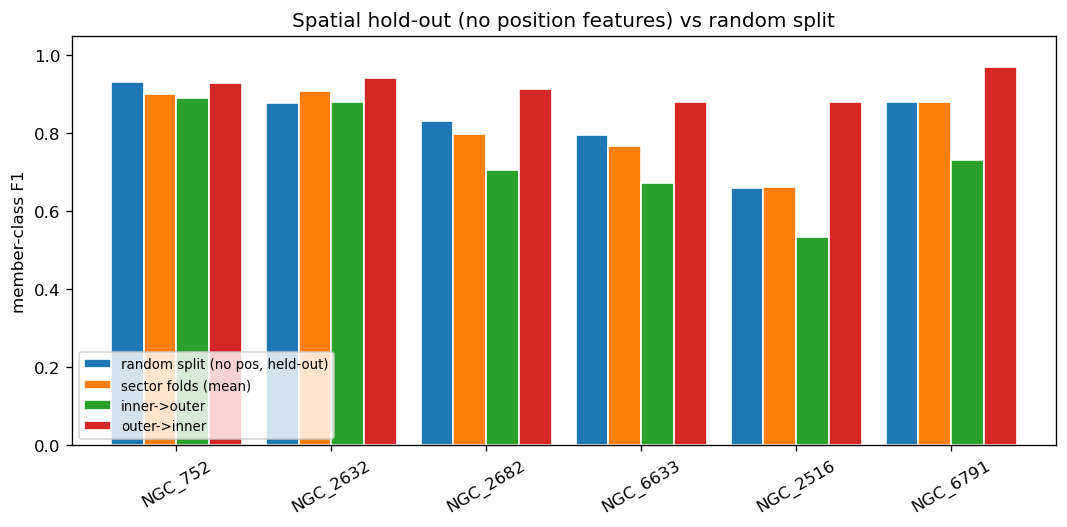

In [73]:

 
def spatial_folds(df):
    ang = np.degrees(np.arctan2(df['delta_dec'], df['delta_ra'])) % 360
    quad = (ang // 90).astype(int)
    r = np.hypot(df['delta_ra'], df['delta_dec'])
    r_half = np.median(r[df['member'] == 1])
    folds = [(f'sector {q}', quad != q, quad == q) for q in range(4)]
    folds += [('inner->outer', r < r_half, r >= r_half), ('outer->inner', r >= r_half, r < r_half)]
    return folds
 
sp_rows = []
for cl in CLUSTERS:
    df = data[cl]
    for name, tr, te in spatial_folds(df):
        if df.loc[te, 'member'].sum() < 5:      # not enough members to score
            continue
        rf = RandomForestClassifier(**RF_KW).fit(df.loc[tr, FEATURES_NOPOS], df.loc[tr, 'member'])
        prob = rf.predict_proba(df.loc[te, FEATURES_NOPOS])[:, 1]
        m = evaluate(df.loc[te, 'member'], (prob >= 0.5).astype(int), prob)
        sp_rows.append(dict(cluster=cl, fold=name, n_test_members=int(df.loc[te, 'member'].sum()), **m))
    print(f'{cl} done')
sp = pd.DataFrame(sp_rows); sp.to_csv(f'{OUT_DIR}/item8_2_spatial_holdout.csv', index=False)
 
sp['scheme'] = np.where(sp['fold'].str.startswith('sector'), 'sector folds (mean)', sp['fold'])
sp_sum = (sp.groupby(['cluster', 'scheme'])[['precision', 'recall', 'f1', 'AP']].mean()
            .unstack('scheme')['f1'].loc[CLUSTERS])
sp_sum['random split (no pos, held-out)'] = [abl[(abl.cluster == c) & (abl.feature_set == 'PM + parallax + phot')]['f1'].iloc[0] for c in CLUSTERS]
sp_sum.round(3)
 
fig, ax = plt.subplots(figsize=(9, 4.5))
cols = ['random split (no pos, held-out)', 'sector folds (mean)', 'inner->outer', 'outer->inner']
sp_sum[cols].plot(kind='bar', ax=ax, width=0.85, edgecolor='white')
ax.set_ylim(0, 1.05); ax.set_ylabel('member-class F1'); ax.set_xlabel('')
ax.set_title('Spatial hold-out (no position features) vs random split')
ax.legend(fontsize=8, loc='lower left'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_2_spatial_holdout.png', dpi=150); plt.show()
 
 

In [77]:

 
nopos_rows = []; oof_nopos = {}
for cl in CLUSTERS:
    df = data[cl]
    _, m, _ = train_rf(df, df['member'], FEATURES_NOPOS)
    oof_nopos[cl] = oof_probabilities(df, df['member'], FEATURES_NOPOS)
    row = dict(cluster=cl, f1_withpos=multi.loc[cl, 'f1'], f1_nopos=m['f1'],
               prec_withpos=multi.loc[cl, 'precision'], prec_nopos=m['precision'],
               AP_withpos=multi.loc[cl, 'AP'], AP_nopos=m['AP'])
    if cl in hr23:
        hr50 = set(hr23[cl].loc[hr23[cl]['prob'] >= 0.5, 'source_id'])
        hr30 = set(hr23[cl].loc[hr23[cl]['prob'] >= 0.3, 'source_id'])
        sid = df['source_id'].astype(np.int64); bright = df['phot_g_mean_mag'] < G_LIM
        hrb = set(sid[bright & sid.isin(hr50)]); rf_ids = set(sid[oof_nopos[cl] >= 0.5])
        row['HR23_recall_Glt18_withpos'] = t4b.loc[cl, 'RF_recall_HR23_Glt18']
        row['HR23_recall_Glt18_nopos']   = len(rf_ids & hrb) / len(hrb) if hrb else np.nan
        newc = rf_ids - set(sid[df['member'] == 1])
        row['new_cands_nopos'] = len(newc); row['new_in_HR23_p30_nopos'] = len(newc & hr30) / len(newc) if newc else np.nan
        row['new_in_HR23_p30_withpos'] = t4b.loc[cl, 'new_frac_p30']
    nopos_rows.append(row)
    print(f'{cl:10s} F1 {row["f1_withpos"]:.2f}->{row["f1_nopos"]:.2f}   HR23 G<18 recall {row.get("HR23_recall_Glt18_withpos", np.nan):.2f}->{row.get("HR23_recall_Glt18_nopos", np.nan):.2f}')
nopos = pd.DataFrame(nopos_rows).set_index('cluster'); nopos.to_csv(f'{OUT_DIR}/item8_3_nopos.csv')
nopos.round(3)
 
 

NGC_752    F1 0.93->0.93   HR23 G<18 recall 0.99->0.99
NGC_2632   F1 0.90->0.88   HR23 G<18 recall 0.98->0.99
NGC_2682   F1 0.91->0.83   HR23 G<18 recall 0.98->0.99
NGC_6633   F1 0.88->0.80   HR23 G<18 recall 0.79->0.92
NGC_2516   F1 0.83->0.66   HR23 G<18 recall 0.92->0.99
NGC_6791   F1 0.96->0.87   HR23 G<18 recall 0.99->0.99


,f1_withpos,f1_nopos,prec_withpos,prec_nopos,AP_withpos,AP_nopos,HR23_recall_Glt18_withpos,HR23_recall_Glt18_nopos,new_cands_nopos,new_in_HR23_p30_nopos,new_in_HR23_p30_withpos
cluster,,,,,,,,,,,
NGC_752,0.932,0.932,0.889,0.889,0.988,0.990,0.989,0.989,36,0.694,0.812
NGC_2632,0.899,0.875,0.831,0.797,0.929,0.884,0.979,0.986,123,0.902,0.882
NGC_2682,0.911,0.832,0.851,0.730,0.932,0.780,0.980,0.989,347,0.847,0.940
NGC_6633,0.882,0.804,0.804,0.683,0.886,0.805,0.785,0.915,106,0.962,0.982
NGC_2516,0.833,0.656,0.717,0.492,0.823,0.656,0.923,0.986,891,0.872,0.944
NGC_6791,0.958,0.873,0.938,0.786,0.968,0.922,0.991,0.991,390,0.108,0.519


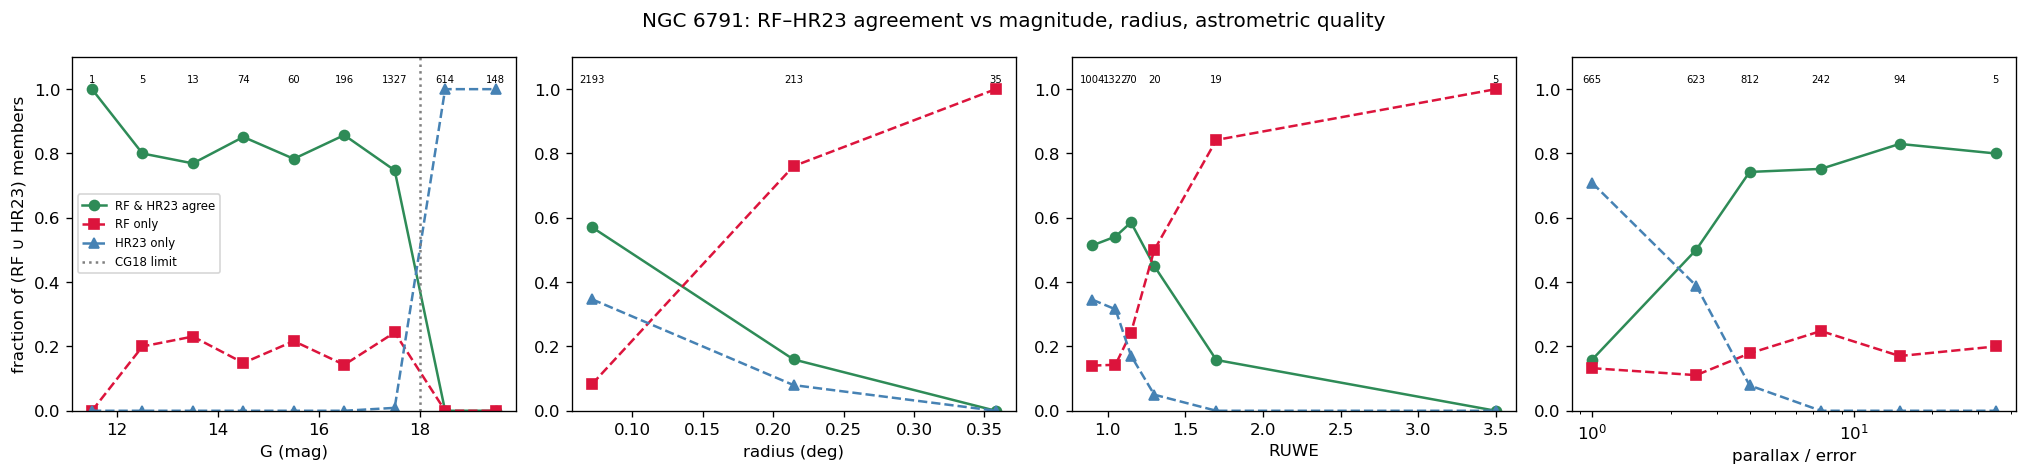

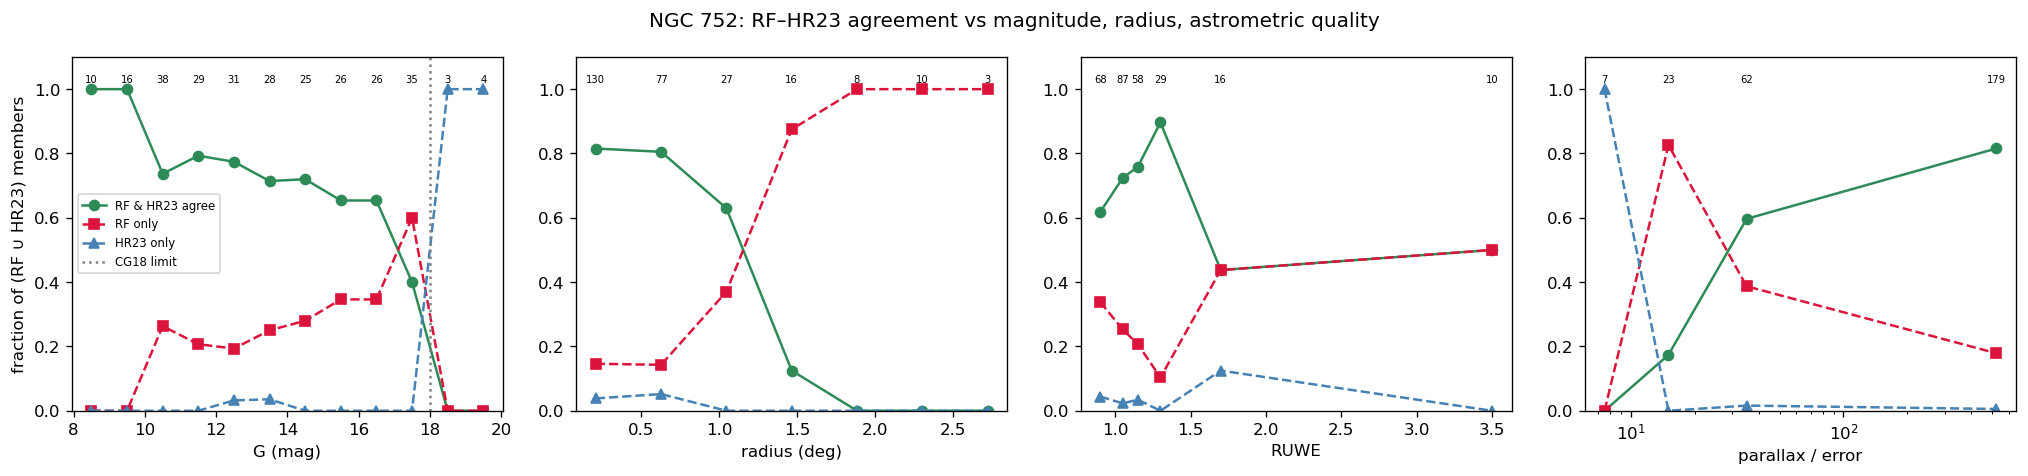

In [79]:

 
def agreement_profile(cl, col, bins):
    df = data[cl].copy()
    qc = f'{OUT_DIR}/{cl}_quality.parquet'
    if os.path.exists(qc) and 'ruwe' not in df.columns:
        df = df.merge(pd.read_parquet(qc), on='source_id', how='left')
    df['r_deg'] = np.hypot(df['delta_ra'], df['delta_dec'])
    rf = df['rf_prob_oof'] >= 0.5; hr = df['hr_prob'] >= 0.5
    either = rf | hr
    d = df[either]
    cat = pd.cut(d[col], bins)
    g = d.groupby(cat, observed=True)
    out = pd.DataFrame({'n_either': g.size(),
                        'agree_frac': g.apply(lambda x: ((x['rf_prob_oof'] >= 0.5) & (x['hr_prob'] >= 0.5)).mean()),
                        'rf_only_frac': g.apply(lambda x: ((x['rf_prob_oof'] >= 0.5) & ~(x['hr_prob'] >= 0.5)).mean()),
                        'hr_only_frac': g.apply(lambda x: (~(x['rf_prob_oof'] >= 0.5) & (x['hr_prob'] >= 0.5)).mean())})
    return out
 
DIAG = [('phot_g_mean_mag', np.arange(8, 21, 1.0), 'G (mag)'),
        ('r_deg', None, 'radius (deg)'),
        ('ruwe', np.array([0.8, 1.0, 1.1, 1.2, 1.4, 2.0, 5.0]), 'RUWE'),
        ('parallax_over_error', np.array([0, 2, 3, 5, 10, 20, 50, 1000]), 'parallax / error')]
 
def diag_figure(cl):
    df = data[cl]; rmax = np.hypot(df['delta_ra'], df['delta_dec']).max()
    fig, axes = plt.subplots(1, 4, figsize=(17, 4))
    for ax, (col, bins, lab) in zip(axes, DIAG):
        b = np.linspace(0, rmax, 8) if bins is None else bins
        prof = agreement_profile(cl, col, b)
        xc = [iv.mid for iv in prof.index]
        ax.plot(xc, prof['agree_frac'], 'o-', color='seagreen', label='RF & HR23 agree')
        ax.plot(xc, prof['rf_only_frac'], 's--', color='crimson', label='RF only')
        ax.plot(xc, prof['hr_only_frac'], '^--', color='steelblue', label='HR23 only')
        for x_, n in zip(xc, prof['n_either']): ax.text(x_, 1.02, str(n), ha='center', fontsize=6)
        ax.set_xlabel(lab); ax.set_ylim(0, 1.1)
        if col == 'parallax_over_error': ax.set_xscale('log')
        if col == 'phot_g_mean_mag': ax.axvline(G_LIM, color='grey', ls=':', label='CG18 limit')
    axes[0].set_ylabel('fraction of (RF ∪ HR23) members'); axes[0].legend(fontsize=7)
    plt.suptitle(f'{cl.replace("_"," ")}: RF–HR23 agreement vs magnitude, radius, astrometric quality')
    plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_4_{cl}_disagreement.png', dpi=150); plt.show()
 
for cl in ['NGC_6791', 'NGC_752']:       # 6791 is the case of interest; 752 shown for contrast
    if cl in hr23: diag_figure(cl)
 
 

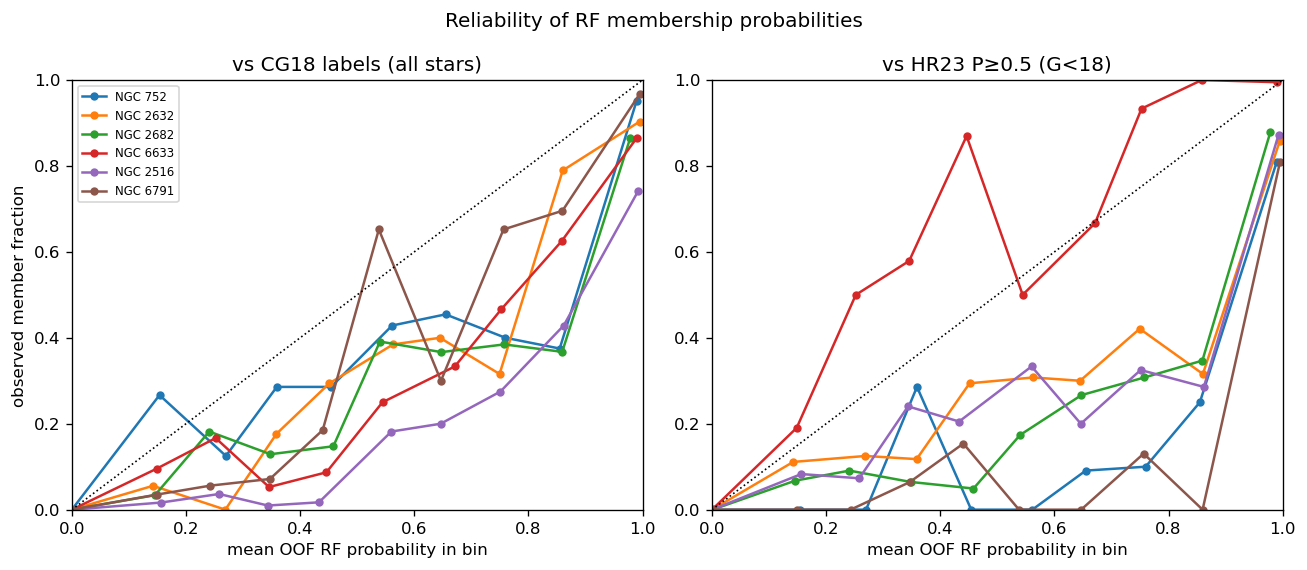

,ECE_vs_CG18,Brier_vs_CG18,ECE_vs_HR23_Glt18,Brier_vs_HR23_Glt18
cluster,,,,
NGC_752,0.000,0.000,0.001,0.001
NGC_2632,0.001,0.001,0.003,0.003
NGC_2682,0.013,0.013,0.032,0.029
NGC_6633,0.000,0.000,0.000,0.000
NGC_2516,0.001,0.001,0.002,0.001
NGC_6791,0.001,0.001,0.011,0.008


In [81]:

 
def reliability(prob, y, nbins=10):
    edges = np.linspace(0, 1, nbins + 1)
    idx = np.clip(np.digitize(prob, edges) - 1, 0, nbins - 1)
    rows = []
    for b in range(nbins):
        m = idx == b
        if m.sum() == 0: continue
        rows.append(dict(bin_mid=(edges[b] + edges[b+1]) / 2, n=int(m.sum()),
                         mean_prob=prob[m].mean(), frac_pos=y[m].mean()))
    r = pd.DataFrame(rows)
    ece = np.sum(r['n'] / len(prob) * np.abs(r['mean_prob'] - r['frac_pos']))
    return r, ece, np.mean((prob - y) ** 2)
 
cal_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for cl in CLUSTERS:
    df = data[cl]; p = df['rf_prob_oof'].values
    r1, ece1, brier1 = reliability(p, df['member'].values.astype(float))
    axes[0].plot(r1['mean_prob'], r1['frac_pos'], 'o-', ms=4, label=cl.replace('_', ' '))
    row = dict(cluster=cl, ECE_vs_CG18=ece1, Brier_vs_CG18=brier1)
    if cl in hr23:
        bright = (df['phot_g_mean_mag'] < G_LIM).values
        yh = (df['hr_prob'] >= 0.5).fillna(False).values.astype(float)
        r2, ece2, brier2 = reliability(p[bright], yh[bright])
        axes[1].plot(r2['mean_prob'], r2['frac_pos'], 'o-', ms=4, label=cl.replace('_', ' '))
        row.update(ECE_vs_HR23_Glt18=ece2, Brier_vs_HR23_Glt18=brier2)
    cal_rows.append(row)
for ax, ttl in zip(axes, ['vs CG18 labels (all stars)', f'vs HR23 P≥0.5 (G<{G_LIM:.0f})']):
    ax.plot([0, 1], [0, 1], 'k:', lw=1); ax.set_xlabel('mean OOF RF probability in bin'); ax.set_title(ttl)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes[0].set_ylabel('observed member fraction'); axes[0].legend(fontsize=7)
plt.suptitle('Reliability of RF membership probabilities'); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/item8_5_calibration.png', dpi=150); plt.show()
cal = pd.DataFrame(cal_rows).set_index('cluster'); cal.to_csv(f'{OUT_DIR}/item8_5_calibration.csv'); cal.round(3)
 
 

In [83]:

 
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
try:
    from sklearn.cluster import HDBSCAN
    HAVE_HDB = True
except ImportError:
    HAVE_HDB = False; print('sklearn.cluster.HDBSCAN unavailable (needs scikit-learn >= 1.3); skipping HDBSCAN')
 
cmp_rows = []
for cl in CLUSTERS:
    df = data[cl]
    Xtr, Xte, ytr, yte = train_test_split(df[FEATURES_ALL], df['member'], test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=df['member'])
    # RF (already have); HGB
    hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, class_weight='balanced',
                                         random_state=RANDOM_STATE).fit(Xtr, ytr)
    ph = hgb.predict_proba(Xte)[:, 1]
    mh = evaluate(yte, (ph >= 0.5).astype(int), ph)
    row = dict(cluster=cl, RF_f1=multi.loc[cl, 'f1'], RF_AP=multi.loc[cl, 'AP'], HGB_f1=mh['f1'], HGB_AP=mh['AP'])
    # HDBSCAN on coarse pre-selection
    if HAVE_HDB:
        r = cl_ref.loc[cl]
        pre = ((df['pmra'] - r.pm_ra0).abs() < 8) & ((df['pmdec'] - r.pm_de0).abs() < 8) & \
              (df['parallax'] > r.plx0 / 2) & (df['parallax'] < r.plx0 * 2)
        sub = df[pre]
        X = StandardScaler().fit_transform(sub[['pmra', 'pmdec', 'parallax']])
        labels = HDBSCAN(min_cluster_size=max(30, int(0.05 * sub['member'].sum())), min_samples=10).fit_predict(X)
        best = (np.nan, np.nan, np.nan)
        for lab in np.unique(labels):
            if lab < 0: continue
            pred = (labels == lab).astype(int)
            f = f1_score(sub['member'], pred, zero_division=0)
            if not (f <= best[0]): best = (f, precision_score(sub['member'], pred, zero_division=0), recall_score(sub['member'], pred, zero_division=0))
        # recall must be computed against ALL labelled members, incl. those outside the pre-selection
        missed_by_presel = int(df['member'].sum() - sub['member'].sum())
        row.update(HDBSCAN_f1_presel=best[0], HDBSCAN_prec=best[1], HDBSCAN_recall_presel=best[2],
                   n_presel=len(sub), members_outside_presel=missed_by_presel)
    cmp_rows.append(row)
    print(f'{cl:10s} RF F1 {row["RF_f1"]:.2f}  HGB F1 {row["HGB_f1"]:.2f}  HDBSCAN F1 {row.get("HDBSCAN_f1_presel", np.nan):.2f}')
methods = pd.DataFrame(cmp_rows).set_index('cluster'); methods.to_csv(f'{OUT_DIR}/item8_6_methods.csv'); methods.round(3)
 
 

NGC_752    RF F1 0.93  HGB F1 0.93  HDBSCAN F1 0.78
NGC_2632   RF F1 0.90  HGB F1 0.90  HDBSCAN F1 0.13
NGC_2682   RF F1 0.91  HGB F1 0.90  HDBSCAN F1 0.60
NGC_6633   RF F1 0.88  HGB F1 0.82  HDBSCAN F1 0.00
NGC_2516   RF F1 0.83  HGB F1 0.83  HDBSCAN F1 0.06
NGC_6791   RF F1 0.96  HGB F1 0.95  HDBSCAN F1 0.12


,RF_f1,RF_AP,HGB_f1,HGB_AP,HDBSCAN_f1_presel,HDBSCAN_prec,HDBSCAN_recall_presel,n_presel,members_outside_presel
cluster,,,,,,,,,
NGC_752,0.932,0.988,0.933,0.986,0.777,0.635,1.000,11051,0
NGC_2632,0.899,0.929,0.903,0.955,0.131,0.862,0.071,1387,0
NGC_2682,0.911,0.932,0.902,0.933,0.597,0.426,1.000,4484,0
NGC_6633,0.882,0.886,0.824,0.851,0.004,0.002,1.000,125117,0
NGC_2516,0.833,0.823,0.826,0.873,0.059,0.030,0.999,38511,0
NGC_6791,0.958,0.968,0.949,0.969,0.116,0.062,0.984,62522,97


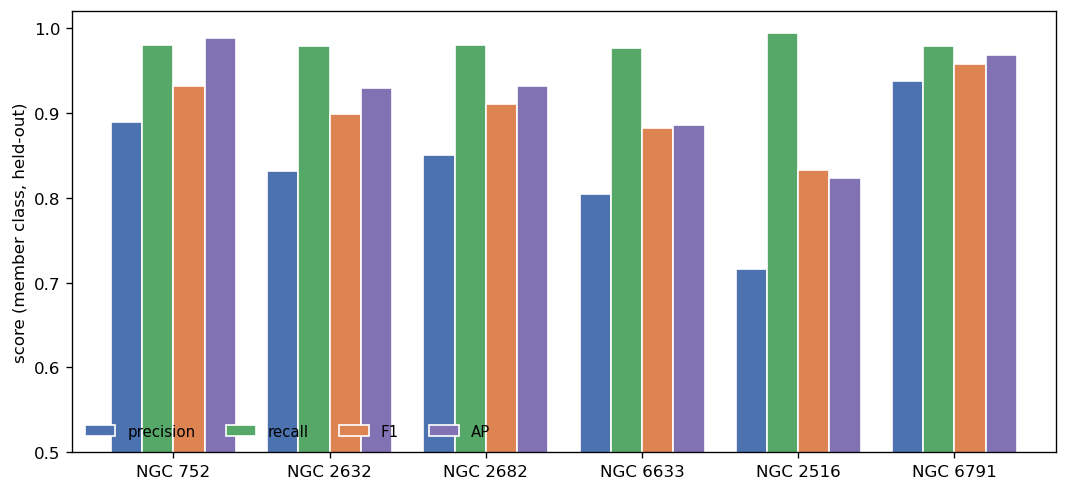

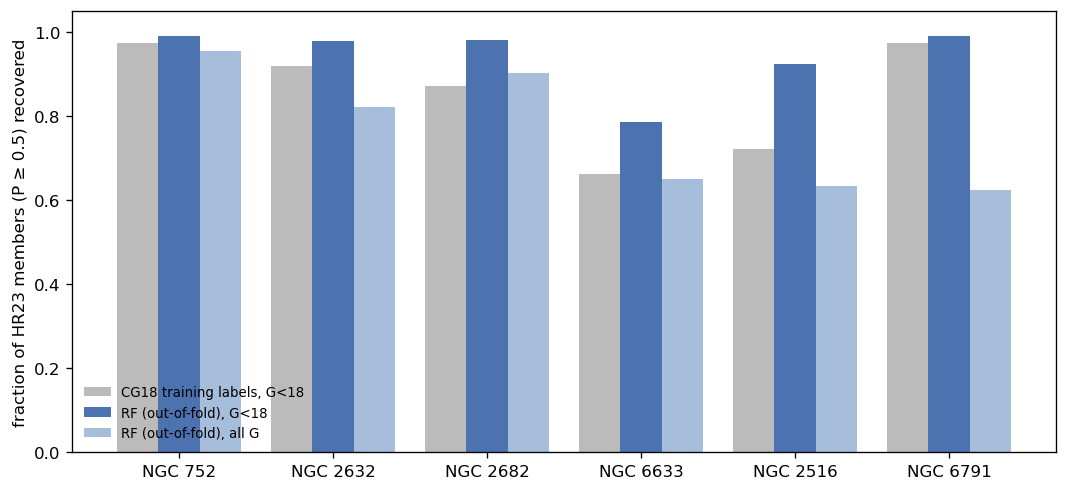

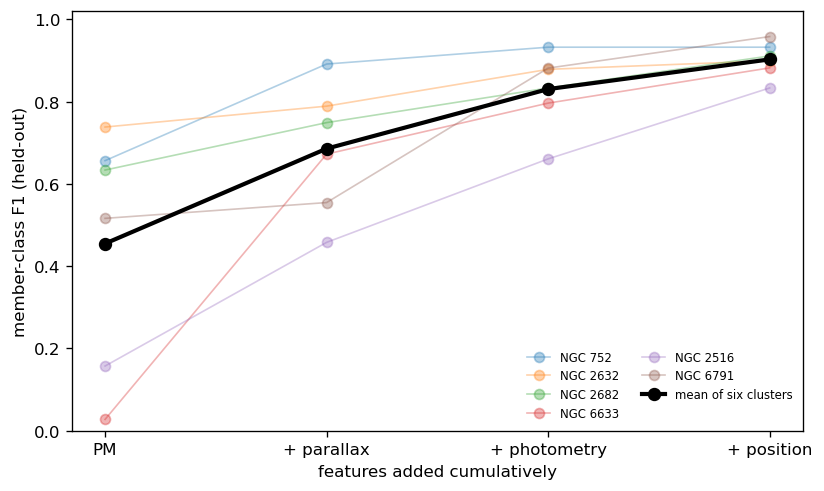

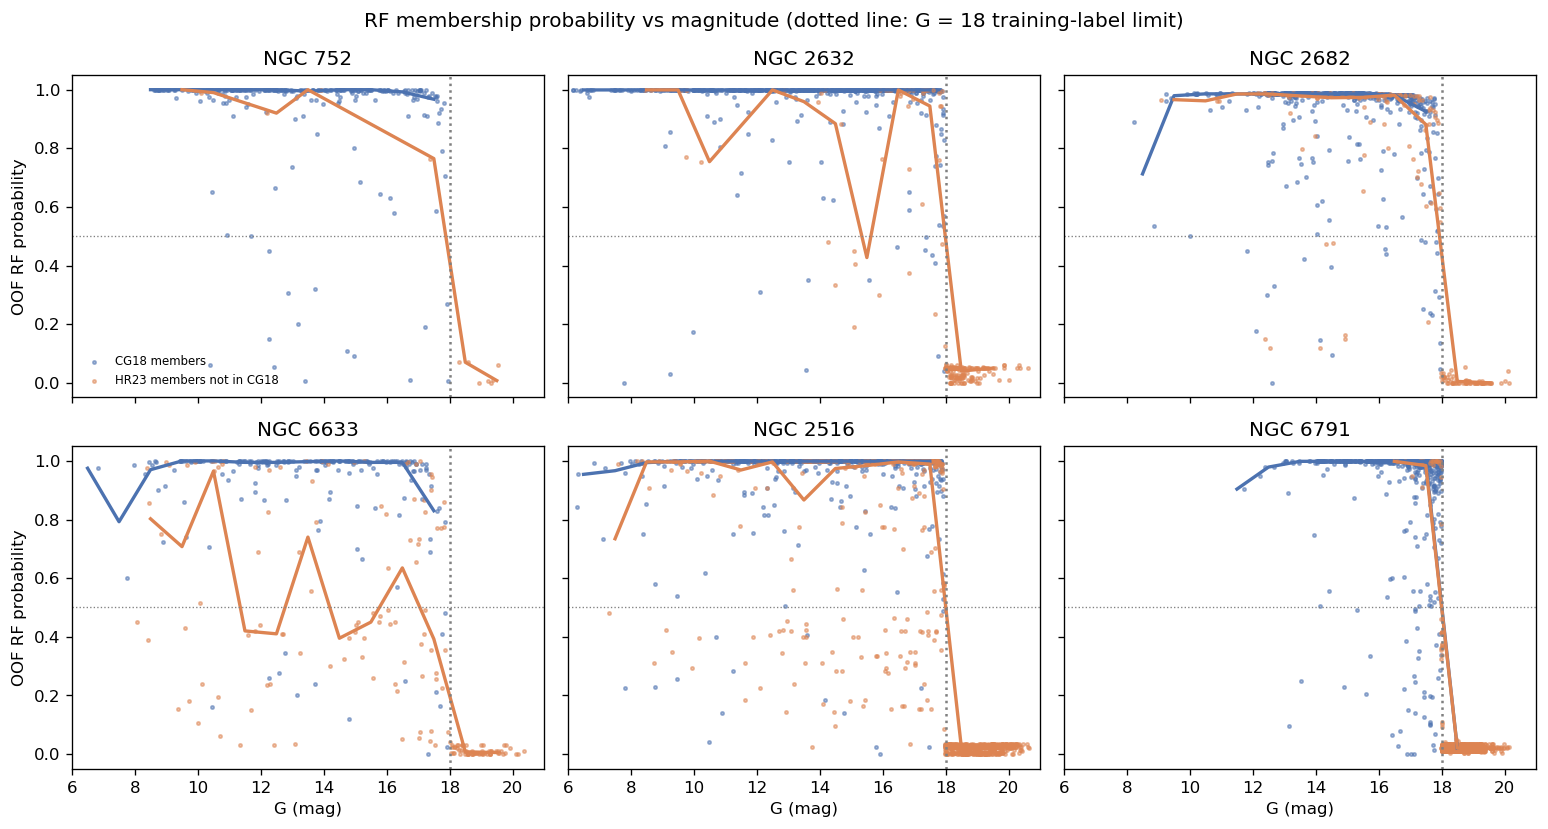

  SECOND-ROUND SUMMARY

8.1 Leave-one-cluster-out (physical features, no position) — F1 on the held-out CLUSTER:
  NGC_752    LOCO F1=0.59 (P=0.42 R=1.00)  vs within-cluster 0.93   HR23 G<18 recall 1.00
  NGC_2632   LOCO F1=0.75 (P=0.84 R=0.68)  vs within-cluster 0.90   HR23 G<18 recall 0.67
  NGC_2682   LOCO F1=0.63 (P=0.46 R=1.00)  vs within-cluster 0.91   HR23 G<18 recall 1.00
  NGC_6633   LOCO F1=0.27 (P=0.15 R=1.00)  vs within-cluster 0.88   HR23 G<18 recall 1.00
  NGC_2516   LOCO F1=0.36 (P=0.22 R=1.00)  vs within-cluster 0.83   HR23 G<18 recall 1.00
  NGC_6791   LOCO F1=0.47 (P=0.75 R=0.34)  vs within-cluster 0.96   HR23 G<18 recall 0.39

8.2 Spatial hold-out (no position) — F1:
scheme    inner->outer  outer->inner  sector folds (mean)  random split (no pos, held-out)
cluster                                                                                   
NGC_752           0.89          0.93                 0.90                             0.93
NGC_2632          0.88          

In [87]:

 

fig, ax = plt.subplots(figsize=(9, 4.2))
multi.loc[CLUSTERS, ['precision', 'recall', 'f1', 'AP']].rename(columns={'f1': 'F1'}).plot(
    kind='bar', ax=ax, width=0.8, edgecolor='white', color=['#4c72b0', '#55a868', '#dd8452', '#8172b3'])
ax.set_ylim(0.5, 1.02); ax.set_ylabel('score (member class, held-out)'); ax.set_xlabel('')
ax.set_xticklabels([c.replace('_', ' ') for c in CLUSTERS], rotation=0)
ax.legend(ncol=4, fontsize=9, loc='lower left', frameon=False)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig1_metrics.png', dpi=200); plt.show()
 

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(t4b)); w = 0.27
ax.bar(x - w, t4b['CG_recall_HR23_Glt18'], w, color='#bbbbbb',  label=f'CG18 training labels, G<{G_LIM:.0f}')
ax.bar(x,     t4b['RF_recall_HR23_Glt18'], w, color='#4c72b0',  label=f'RF (out-of-fold), G<{G_LIM:.0f}')
ax.bar(x + w, t4b['RF_recall_HR23_all'],   w, color='#a6bddb',  label='RF (out-of-fold), all G')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_', ' ') for c in t4b.index], rotation=0)
ax.set_ylim(0, 1.05); ax.set_ylabel('fraction of HR23 members (P ≥ 0.5) recovered')
ax.legend(fontsize=8, loc='lower left', frameon=False)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig2_hr23_completeness.png', dpi=200); plt.show()
 

steps = ['PM only', 'PM + parallax', 'PM + parallax + phot', 'all 9 features']
step_lab = ['PM', '+ parallax', '+ photometry', '+ position']
fig, ax = plt.subplots(figsize=(7, 4.2))
for cl in CLUSTERS:
    y = [abl[(abl.cluster == cl) & (abl.feature_set == s_)]['f1'].iloc[0] for s_ in steps]
    ax.plot(step_lab, y, 'o-', alpha=0.35, lw=1, label=cl.replace('_', ' '))
ax.plot(step_lab, f1_table.loc[steps, 'mean'], 'ko-', lw=2.5, ms=7, label='mean of six clusters')
ax.set_ylim(0, 1.02); ax.set_ylabel('member-class F1 (held-out)'); ax.set_xlabel('features added cumulatively')
ax.legend(fontsize=7, ncol=2, frameon=False, loc='lower right')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig3_ablation_incremental.png', dpi=200); plt.show()
 

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, cl in zip(axes.ravel(), CLUSTERS):
    df = data[cl]; cat = df['member'] == 1
    hr_new = (df['hr_prob'] >= 0.5) & ~cat if 'hr_prob' in df else pd.Series(False, index=df.index)
    ax.scatter(df.loc[cat, 'phot_g_mean_mag'], df.loc[cat, 'rf_prob_oof'], s=4, c='#4c72b0', alpha=0.5, label='CG18 members')
    ax.scatter(df.loc[hr_new, 'phot_g_mean_mag'], df.loc[hr_new, 'rf_prob_oof'], s=4, c='#dd8452', alpha=0.5, label='HR23 members not in CG18')
    gb = np.arange(6, 21, 1.0)
    for sel, colr in [(cat, '#4c72b0'), (hr_new, '#dd8452')]:
        d = df[sel]
        if len(d) == 0: continue
        med = d.groupby(pd.cut(d['phot_g_mean_mag'], gb), observed=True)['rf_prob_oof'].median()
        ax.plot([iv.mid for iv in med.index], med.values, '-', color=colr, lw=2)
    ax.axvline(G_LIM, color='grey', ls=':'); ax.axhline(0.5, color='grey', ls=':', lw=0.8)
    ax.set_title(cl.replace('_', ' ')); ax.set_xlim(6, 21)
for ax in axes[1]: ax.set_xlabel('G (mag)')
for ax in axes[:, 0]: ax.set_ylabel('OOF RF probability')
axes[0, 0].legend(fontsize=7, loc='lower left', frameon=False)
plt.suptitle('RF membership probability vs magnitude (dotted line: G = 18 training-label limit)')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig4_prob_vs_G.png', dpi=200); plt.show()
 
print('=' * 72); print('  SECOND-ROUND SUMMARY'); print('=' * 72)
print('\n8.1 Leave-one-cluster-out (physical features, no position) — F1 on the held-out CLUSTER:')
for _, r in loco[loco.feature_set == 'physical, no position'].iterrows():
    print(f'  {r.target:10s} LOCO F1={r.f1:.2f} (P={r.precision:.2f} R={r.recall:.2f})  vs within-cluster {r.within_cluster_f1:.2f}'
          + (f'   HR23 G<18 recall {r.HR23_recall_Glt18:.2f}' if pd.notna(r.get('HR23_recall_Glt18', np.nan)) else ''))
print('\n8.2 Spatial hold-out (no position) — F1:')
print(sp_sum.round(2).to_string())
print('\n8.3 Without position features:')
for cl, r in nopos.iterrows():
    print(f'  {cl:10s} F1 {r.f1_withpos:.2f}->{r.f1_nopos:.2f}   HR23 G<18 recall {r.get("HR23_recall_Glt18_withpos", np.nan):.2f}->{r.get("HR23_recall_Glt18_nopos", np.nan):.2f}'
          f'   new-cand conf. {r.get("new_in_HR23_p30_withpos", np.nan):.0%}->{r.get("new_in_HR23_p30_nopos", np.nan):.0%}')
print('\n8.5 Calibration:'); print(cal.round(3).to_string())
print('\n8.6 Methods:'); print(methods[[c for c in methods.columns if 'f1' in c.lower() or 'AP' in c]].round(2).to_string())
 

In [89]:
for cl in CLUSTERS:
    y = data[cl]['member'].values; p = loco_prob[cl]
    ap = average_precision_score(y, p)
    best = max(((f1_score(y, (p>=t).astype(int)), t) for t in np.arange(0.5, 0.99, 0.02)))
    print(f'{cl:10s} LOCO AP={ap:.2f}   best F1={best[0]:.2f} at threshold {best[1]:.2f}')

NGC_752    LOCO AP=0.89   best F1=0.87 at threshold 0.98
NGC_2632   LOCO AP=0.82   best F1=0.75 at threshold 0.60
NGC_2682   LOCO AP=0.70   best F1=0.75 at threshold 0.96
NGC_6633   LOCO AP=0.65   best F1=0.66 at threshold 0.98
NGC_2516   LOCO AP=0.48   best F1=0.56 at threshold 0.98
NGC_6791   LOCO AP=0.62   best F1=0.47 at threshold 0.50


In [93]:

from sklearn.ensemble import HistGradientBoostingClassifier

cmp_rows = []
for cl in CLUSTERS:
    df = data[cl]
    Xtr, Xte, ytr, yte = train_test_split(df[FEATURES_ALL], df['member'], test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=df['member'])
    hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                         class_weight='balanced',
                                         random_state=RANDOM_STATE).fit(Xtr, ytr)
    ph = hgb.predict_proba(Xte)[:, 1]
    mh = evaluate(yte, (ph >= 0.5).astype(int), ph)
    cmp_rows.append(dict(cluster=cl,
                         RF_f1=multi.loc[cl, 'f1'],  RF_AP=multi.loc[cl, 'AP'],
                         RF_prec=multi.loc[cl, 'precision'], RF_rec=multi.loc[cl, 'recall'],
                         HGB_f1=mh['f1'], HGB_AP=mh['AP'],
                         HGB_prec=mh['precision'], HGB_rec=mh['recall']))
    print(f'{cl:10s} RF F1 {cmp_rows[-1]["RF_f1"]:.2f} / AP {cmp_rows[-1]["RF_AP"]:.2f}   '
          f'HGB F1 {mh["f1"]:.2f} / AP {mh["AP"]:.2f}')

methods = pd.DataFrame(cmp_rows).set_index('cluster')
methods.to_csv(f'{OUT_DIR}/item8_6_methods.csv')
methods.round(3)

NGC_752    RF F1 0.93 / AP 0.99   HGB F1 0.93 / AP 0.99
NGC_2632   RF F1 0.90 / AP 0.93   HGB F1 0.90 / AP 0.96
NGC_2682   RF F1 0.91 / AP 0.93   HGB F1 0.90 / AP 0.93
NGC_6633   RF F1 0.88 / AP 0.89   HGB F1 0.82 / AP 0.85
NGC_2516   RF F1 0.83 / AP 0.82   HGB F1 0.83 / AP 0.87
NGC_6791   RF F1 0.96 / AP 0.97   HGB F1 0.95 / AP 0.97


,RF_f1,RF_AP,RF_prec,RF_rec,HGB_f1,HGB_AP,HGB_prec,HGB_rec
cluster,,,,,,,,
NGC_752,0.932,0.988,0.889,0.980,0.933,0.986,0.875,1.000
NGC_2632,0.899,0.929,0.831,0.979,0.903,0.955,0.828,0.993
NGC_2682,0.911,0.932,0.851,0.980,0.902,0.933,0.836,0.980
NGC_6633,0.882,0.886,0.804,0.976,0.824,0.851,0.700,1.000
NGC_2516,0.833,0.823,0.717,0.995,0.826,0.873,0.710,0.989
NGC_6791,0.958,0.968,0.938,0.978,0.949,0.969,0.924,0.975


In [97]:

def bootstrap_ci(y, p, n_boot=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y = np.asarray(y); p = np.asarray(p); idx = np.arange(len(y))
    stats = []
    for _ in range(n_boot):
        b = rng.choice(idx, len(idx), replace=True)
        yb, pb = y[b], p[b]
        if yb.sum() == 0 or yb.sum() == len(yb): continue
        yh = (pb >= 0.5).astype(int)
        stats.append([precision_score(yb, yh, zero_division=0),
                      recall_score(yb, yh, zero_division=0),
                      f1_score(yb, yh, zero_division=0),
                      average_precision_score(yb, pb)])
    lo, hi = np.percentile(np.array(stats), [2.5, 97.5], axis=0)
    return lo, hi

def fmt(v, lo, hi):
    return f"${v:.2f}^{{+{hi-v:.2f}}}_{{-{v-lo:.2f}}}$"

print(r"Cluster & Distance (pc) & Labelled members & Precision & Recall & F1 & AP & TP & FP & FN\\")
print(r"\hline")
ci_rows = []
for cl in CLUSTERS:
    df = data[cl]
    Xtr, Xte, ytr, yte = train_test_split(df[FEATURES_ALL], df['member'], test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=df['member'])
    rf = RandomForestClassifier(**RF_KW).fit(Xtr, ytr)
    p = rf.predict_proba(Xte)[:, 1]; y = yte.values
    yh = (p >= 0.5).astype(int)
    vals = [precision_score(y, yh), recall_score(y, yh), f1_score(y, yh),
            average_precision_score(y, p)]
    lo, hi = bootstrap_ci(y, p)
    cm = confusion_matrix(y, yh, labels=[0, 1])
    cells = " & ".join(fmt(v, l, h) for v, l, h in zip(vals, lo, hi))
    name = cl.replace('_', ' ')
    print(f"{name} & {cl_info.loc[cl,'dist_pc']:.0f} & {int(df['member'].sum())} & {cells} "
          f"& {cm[1,1]} & {cm[0,1]} & {cm[1,0]}\\\\")
    ci_rows.append(dict(cluster=cl, **{m: v for m, v in zip(['prec','rec','f1','AP'], vals)},
                        **{f'{m}_lo': l for m, l in zip(['prec','rec','f1','AP'], lo)},
                        **{f'{m}_hi': h for m, h in zip(['prec','rec','f1','AP'], hi)}))
pd.DataFrame(ci_rows).to_csv(f'{OUT_DIR}/table2_bootstrap_ci.csv', index=False)

Cluster & Distance (pc) & Labelled members & Precision & Recall & F1 & AP & TP & FP & FN\\
\hline
NGC 752 & 441 & 245 & $0.89^{+0.07}_{-0.09}$ & $0.98^{+0.02}_{-0.05}$ & $0.93^{+0.04}_{-0.06}$ & $0.99^{+0.01}_{-0.02}$ & 48 & 6 & 1\\
NGC 2632 & 186 & 706 & $0.83^{+0.06}_{-0.06}$ & $0.98^{+0.02}_{-0.03}$ & $0.90^{+0.03}_{-0.04}$ & $0.93^{+0.04}_{-0.05}$ & 138 & 28 & 3\\
NGC 2682 & 859 & 754 & $0.85^{+0.05}_{-0.05}$ & $0.98^{+0.02}_{-0.02}$ & $0.91^{+0.03}_{-0.03}$ & $0.93^{+0.04}_{-0.05}$ & 148 & 26 & 3\\
NGC 6633 & 392 & 209 & $0.80^{+0.11}_{-0.11}$ & $0.98^{+0.02}_{-0.06}$ & $0.88^{+0.07}_{-0.08}$ & $0.89^{+0.08}_{-0.11}$ & 41 & 10 & 1\\
NGC 2516 & 409 & 913 & $0.72^{+0.06}_{-0.06}$ & $0.99^{+0.01}_{-0.01}$ & $0.83^{+0.04}_{-0.04}$ & $0.82^{+0.06}_{-0.06}$ & 182 & 72 & 1\\
NGC 6791 & 4531 & 1623 & $0.94^{+0.03}_{-0.03}$ & $0.98^{+0.01}_{-0.02}$ & $0.96^{+0.01}_{-0.02}$ & $0.97^{+0.02}_{-0.03}$ & 318 & 21 & 7\\


In [99]:

for cl in CLUSTERS:
    if cl not in hr23: continue
    df = data[cl]; sid = df['source_id'].astype(np.int64)
    hr50 = set(hr23[cl].loc[hr23[cl]['prob'] >= 0.5, 'source_id'])
    n_all = int(sid.isin(hr50).sum())
    n_b18 = int((sid.isin(hr50) & (df['phot_g_mean_mag'] < G_LIM)).sum())
    print(f"{cl:10s}  N_HR23(in cone) = {n_all:5d}   N_HR23(G<18) = {n_b18:5d}")

NGC_752     N_HR23(in cone) =   196   N_HR23(G<18) =   189
NGC_2632    N_HR23(in cone) =   791   N_HR23(G<18) =   664
NGC_2682    N_HR23(in cone) =   807   N_HR23(G<18) =   744
NGC_6633    N_HR23(in cone) =   370   N_HR23(G<18) =   307
NGC_2516    N_HR23(in cone) =  1651   N_HR23(G<18) =  1133
NGC_6791    N_HR23(in cone) =  2062   N_HR23(G<18) =  1297


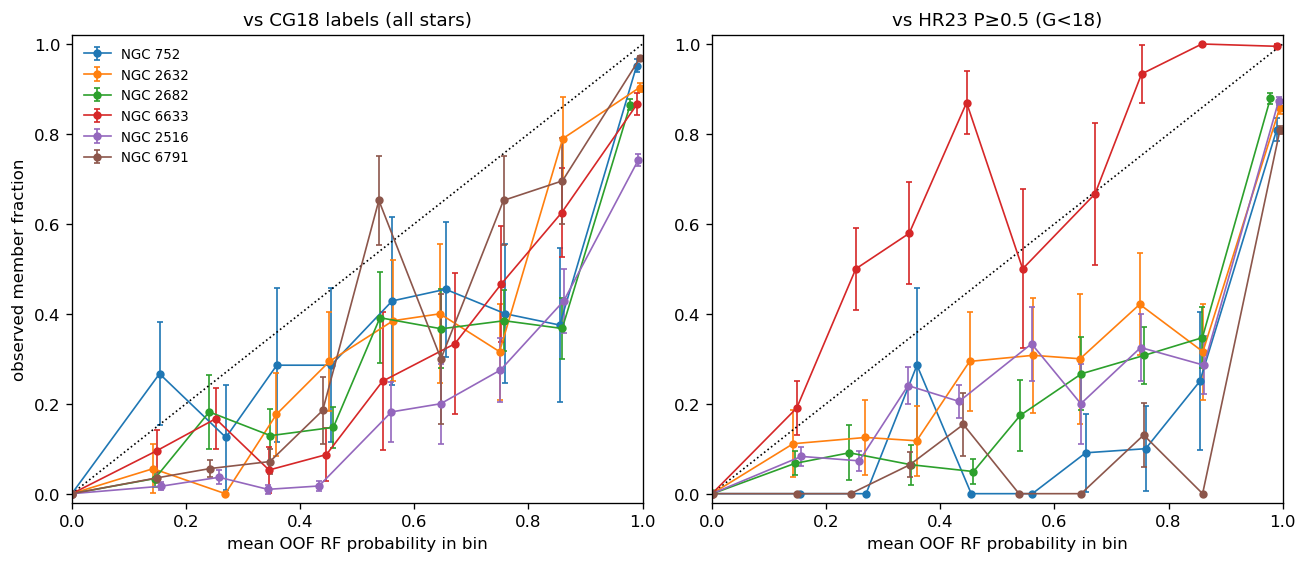

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for cl in CLUSTERS:
    df = data[cl]; p = df['rf_prob_oof'].values
    for ax_i, (yv, ok) in enumerate([(df['member'].values.astype(float), True),
        (((df['hr_prob'] >= 0.5).fillna(False)).values.astype(float),
         cl in hr23)]):
        if not ok: continue
        sel = np.ones(len(df), bool) if ax_i == 0 else (df['phot_g_mean_mag'] < G_LIM).values
        r, ece, _ = reliability(p[sel], yv[sel])
        err = np.sqrt(r['frac_pos'] * (1 - r['frac_pos']) / r['n'])
        axes[ax_i].errorbar(r['mean_prob'], r['frac_pos'], yerr=err, fmt='o-', ms=4,
                            lw=1, capsize=2, label=cl.replace('_', ' '))
for ax, ttl in zip(axes, ['vs CG18 labels (all stars)', f'vs HR23 P≥0.5 (G<{G_LIM:.0f})']):
    ax.plot([0, 1], [0, 1], 'k:', lw=1)
    ax.set_xlabel('mean OOF RF probability in bin'); ax.set_title(ttl, fontsize=11)
    ax.set_xlim(0, 1); ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel('observed member fraction')
axes[0].legend(fontsize=8, frameon=False, loc='upper left')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_5_calibration.png', dpi=200); plt.show()

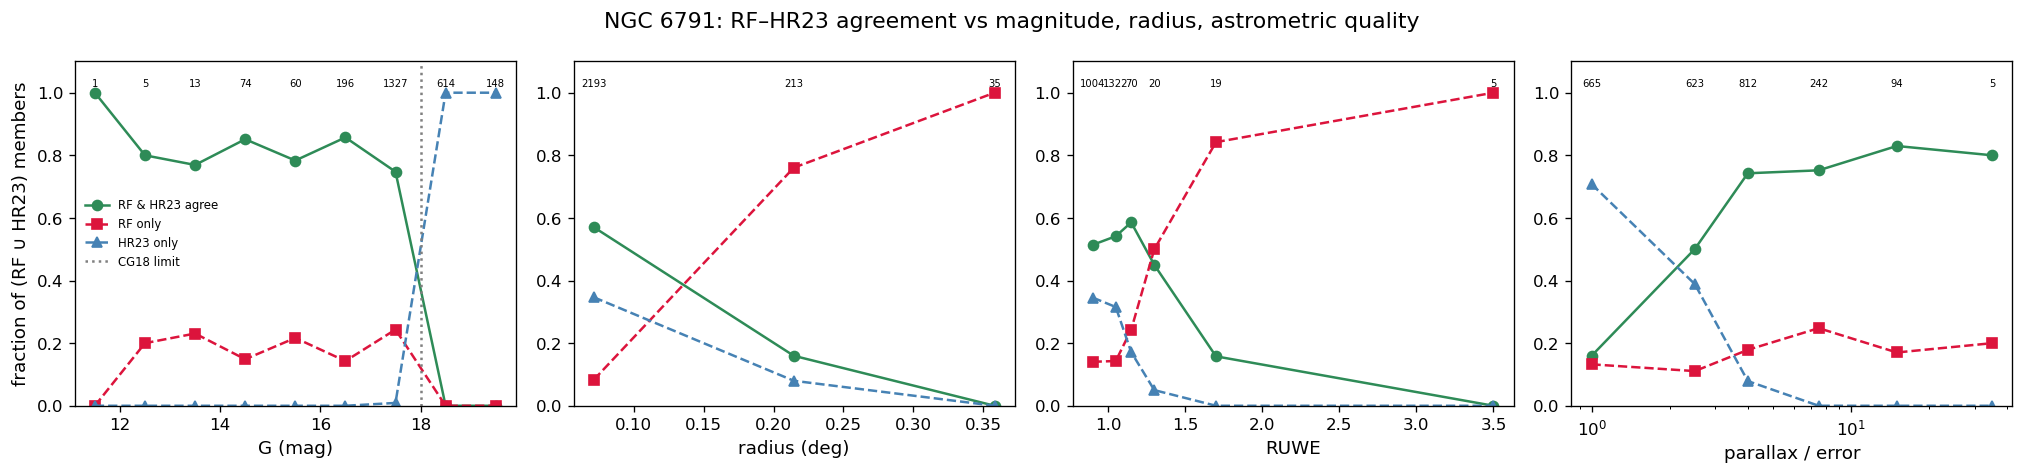

All paper figures regenerated at 200 dpi with uniform styling in outputs_extended


In [103]:

import matplotlib as mpl
mpl.rcParams.update({'font.size': 11, 'axes.titlesize': 11, 'axes.labelsize': 11,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10,
                     'legend.fontsize': 9, 'legend.frameon': False,
                     'savefig.dpi': 200, 'savefig.bbox': 'tight'})
NICE = [c.replace('_', ' ') for c in CLUSTERS]


fig, ax = plt.subplots(figsize=(8.5, 4))
multi.loc[CLUSTERS, ['precision', 'recall', 'f1', 'AP']].rename(columns={'f1': 'F1'}).plot(
    kind='bar', ax=ax, width=0.8, edgecolor='white',
    color=['#4c72b0', '#55a868', '#dd8452', '#8172b3'])
ax.set_ylim(0.5, 1.02); ax.set_ylabel('score (member class, held-out)'); ax.set_xlabel('')
ax.set_xticklabels(NICE, rotation=0); ax.legend(ncol=4, loc='lower left')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig1_metrics.png'); plt.close()


n = len(CLUSTERS); fig, axes = plt.subplots(2, n, figsize=(3.1*n, 6.6))
for j, cl in enumerate(CLUSTERS):
    df = data[cl]; mem = df['member'] == 1; rfm = df['rf_prob_oof'] >= 0.5
    for i, (mask, ttl) in enumerate([(mem, 'CG18 members'), (rfm, 'RF members (OOF)')]):
        ax = axes[i, j]
        ax.scatter(df['pmra'], df['pmdec'], s=0.3, c='lightgrey', alpha=0.3, rasterized=True)
        ax.scatter(df.loc[mask, 'pmra'], df.loc[mask, 'pmdec'], s=4, c='crimson')
        c = df.loc[mem, ['pmra', 'pmdec']].median()
        ax.set_xlim(c.pmra-10, c.pmra+10); ax.set_ylim(c.pmdec-10, c.pmdec+10)
        if i == 0: ax.set_title(NICE[j], fontsize=10)
        ax.text(0.03, 0.95, f'{ttl}\nn={int(mask.sum())}', transform=ax.transAxes,
                fontsize=8, va='top')
        if j == 0: ax.set_ylabel(r'$\mu_\delta$ (mas yr$^{-1}$)')
        if i == 1: ax.set_xlabel(r'$\mu_{\alpha^*}$ (mas yr$^{-1}$)')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item1_pm_panels.png'); plt.close()


fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(t4b)); w = 0.27
ax.bar(x-w, t4b['CG_recall_HR23_Glt18'], w, color='#bbbbbb', label='CG18 labels, G<18')
ax.bar(x,   t4b['RF_recall_HR23_Glt18'], w, color='#4c72b0', label='RF (OOF), G<18')
ax.bar(x+w, t4b['RF_recall_HR23_all'],   w, color='#a6bddb', label='RF (OOF), all G')
ax.set_xticks(x); ax.set_xticklabels([c.replace('_',' ') for c in t4b.index], rotation=0)
ax.set_ylim(0, 1.05); ax.set_ylabel('fraction of HR23 members recovered')
ax.legend(loc='lower left')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig2_hr23_completeness.png'); plt.close()


fig, axes = plt.subplots(2, 3, figsize=(12.5, 7), sharex=True, sharey=True)
for ax, cl in zip(axes.ravel(), CLUSTERS):
    df = data[cl]; cat = df['member'] == 1
    hr_new = (df['hr_prob'] >= 0.5) & ~cat
    ax.scatter(df.loc[cat, 'phot_g_mean_mag'], df.loc[cat, 'rf_prob_oof'], s=4,
               c='#4c72b0', alpha=0.45)
    ax.scatter(df.loc[hr_new, 'phot_g_mean_mag'], df.loc[hr_new, 'rf_prob_oof'], s=4,
               c='#dd8452', alpha=0.45)
    gb = np.arange(6, 21, 1.0)
    for sel, colr in [(cat, '#4c72b0'), (hr_new, '#dd8452')]:
        d = df[sel]
        if len(d) == 0: continue
        med = d.groupby(pd.cut(d['phot_g_mean_mag'], gb), observed=True)['rf_prob_oof'].median()
        ax.plot([iv.mid for iv in med.index], med.values, '-', color=colr, lw=2.2)
    ax.axvline(G_LIM, color='grey', ls=':'); ax.axhline(0.5, color='grey', ls=':', lw=0.7)
    ax.set_title(cl.replace('_', ' '), fontsize=10); ax.set_xlim(6, 21)
for ax in axes[1]: ax.set_xlabel('G (mag)')
for ax in axes[:, 0]: ax.set_ylabel('OOF RF probability')
from matplotlib.lines import Line2D
axes[0, 0].legend(handles=[Line2D([], [], color='#4c72b0', marker='o', ls='-', label='CG18 members'),
                           Line2D([], [], color='#dd8452', marker='o', ls='-', label='HR23 members not in CG18')],
                  loc='lower left')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig4_prob_vs_G.png'); plt.close()


cl = 'NGC_752'; df = data[cl]
cat = df['member'] == 1; rfm = df['rf_prob_oof'] >= 0.5; new = rfm & ~cat
conf = new & (df['hr_prob'] >= 0.3); unconf = new & ~(df['hr_prob'] >= 0.3)
r = np.hypot(df['delta_ra'], df['delta_dec'])
fig, axes3 = plt.subplots(1, 3, figsize=(14.5, 4.4))
ax = axes3[0]
ax.scatter(df['bp_rp'], df['phot_g_mean_mag'], s=0.3, c='lightgrey', alpha=0.3, rasterized=True)
ax.scatter(df.loc[cat,'bp_rp'], df.loc[cat,'phot_g_mean_mag'], s=6, c='steelblue', label=f'CG18 members ({cat.sum()})')
ax.scatter(df.loc[conf,'bp_rp'], df.loc[conf,'phot_g_mean_mag'], s=30, marker='^', c='seagreen', label=f'new, HR23 P$\\geq$0.3 ({conf.sum()})')
ax.scatter(df.loc[unconf,'bp_rp'], df.loc[unconf,'phot_g_mean_mag'], s=30, marker='^', c='crimson', label=f'new, HR23 P$<$0.3 ({unconf.sum()})')
ax.invert_yaxis(); ax.set_xlim(-0.5, 3.5); ax.set_xlabel('BP $-$ RP (mag)'); ax.set_ylabel('G (mag)'); ax.legend(loc='lower left')
ax = axes3[1]
c = df.loc[cat, ['pmra','pmdec']].median()
ax.scatter(df['pmra'], df['pmdec'], s=0.3, c='lightgrey', alpha=0.3, rasterized=True)
ax.scatter(df.loc[cat,'pmra'], df.loc[cat,'pmdec'], s=6, c='steelblue')
ax.scatter(df.loc[conf,'pmra'], df.loc[conf,'pmdec'], s=30, marker='^', c='seagreen')
ax.scatter(df.loc[unconf,'pmra'], df.loc[unconf,'pmdec'], s=30, marker='^', c='crimson')
ax.set_xlim(c.pmra-6, c.pmra+6); ax.set_ylim(c.pmdec-6, c.pmdec+6)
ax.set_xlabel(r'$\mu_{\alpha^*}$ (mas yr$^{-1}$)'); ax.set_ylabel(r'$\mu_\delta$ (mas yr$^{-1}$)')
ax = axes3[2]
bins = np.linspace(0, r[rfm | cat].max()*1.05, 20)
ax.hist(r[cat], bins, alpha=0.6, color='steelblue', density=True, label='CG18 members')
ax.hist(r[conf], bins, alpha=0.6, color='seagreen', density=True, label='new, HR23 P$\\geq$0.3')
ax.hist(r[unconf], bins, alpha=0.6, color='crimson', density=True, label='new, HR23 P$<$0.3')
ax.set_xlabel('radius from centre (deg)'); ax.set_ylabel('density'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item2b_NGC_752_candidates.png'); plt.close()

steps = ['PM only', 'PM + parallax', 'PM + parallax + phot', 'all 9 features']
step_lab = ['PM', '+ parallax', '+ photometry', '+ position']
fig, ax = plt.subplots(figsize=(6.8, 4.2))
for cl_, nm in zip(CLUSTERS, NICE):
    y = [abl[(abl.cluster == cl_) & (abl.feature_set == s_)]['f1'].iloc[0] for s_ in steps]
    ax.plot(step_lab, y, 'o-', alpha=0.35, lw=1.2, label=nm)
ax.plot(step_lab, f1_table.loc[steps, 'mean'], 'ko-', lw=2.6, ms=7, label='mean')
ax.set_ylim(0, 1.02); ax.set_ylabel('member-class F1 (held-out)')
ax.set_xlabel('features added cumulatively'); ax.legend(ncol=2, loc='lower right')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_fig3_ablation_incremental.png'); plt.close()


fig, axes2 = plt.subplots(1, 3, figsize=(13.5, 4))
for cl_, nm in zip(CLUSTERS, NICE):
    sub = thr[thr.cluster == cl_]
    axes2[0].plot(sub.threshold, sub.precision, 'o-', label=nm)
    axes2[1].plot(sub.threshold, sub.recall, 'o-')
    axes2[2].plot(sub.threshold, sub.n_selected/sub.n_selected.iloc[1], 'o-')
axes2[0].set_ylabel('precision (vs CG18)'); axes2[1].set_ylabel('recall (vs CG18)')
axes2[2].set_ylabel('N selected / N at 0.5'); axes2[2].axhline(1, color='grey', lw=0.6)
for ax in axes2: ax.set_xlabel('probability threshold'); ax.set_xticks(THRESHOLDS)
axes2[0].legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item5_threshold_sensitivity.png'); plt.close()


fig, ax = plt.subplots(figsize=(8.5, 4.2)); x = np.arange(len(CLUSTERS)); w = 0.36
ax.bar(x - w/2, multi.loc[CLUSTERS, 'f1'], w, color='steelblue', label='within-cluster (random split)')
ax.bar(x + w/2, loco_a.set_index('target').loc[CLUSTERS, 'f1'], w, color='darkorange',
       label='leave-one-cluster-out')
ax.set_xticks(x); ax.set_xticklabels(NICE, rotation=0)
ax.set_ylim(0, 1.05); ax.set_ylabel('member-class F1'); ax.legend(loc='upper right')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_1b_loco_v2.png'); plt.close()


fig, ax = plt.subplots(figsize=(8.5, 4.2))
cols = ['random split (no pos, held-out)', 'sector folds (mean)', 'inner->outer', 'outer->inner']
sp_sum[cols].plot(kind='bar', ax=ax, width=0.85, edgecolor='white')
ax.set_ylim(0, 1.05); ax.set_ylabel('member-class F1'); ax.set_xlabel('')
ax.set_xticklabels(NICE, rotation=0); ax.legend(loc='lower left')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/item8_2_spatial_holdout.png'); plt.close()


diag_figure('NGC_6791')   
print('All paper figures regenerated at 200 dpi with uniform styling in', OUT_DIR)

In [109]:

from zero_point import zpt
zpt.load_tables()

def zpcols_by_ids(source_ids, cluster, chunk=50000, tries=4, wait=60):
    ids = np.asarray(source_ids, dtype=np.int64)
    cdir = f'{OUT_DIR}/{cluster}_zchunks'; os.makedirs(cdir, exist_ok=True)
    parts = []
    for i in range(0, len(ids), chunk):
        cf = f'{cdir}/chunk_{i}.parquet'
        if os.path.exists(cf):
            parts.append(pd.read_parquet(cf)); continue
        t = Table({'source_id': ids[i:i+chunk]})
        q = ("SELECT g.source_id, g.nu_eff_used_in_astrometry, g.pseudocolour, "
             "g.ecl_lat, g.astrometric_params_solved "
             "FROM gaiadr3.gaia_source AS g JOIN tap_upload.ids AS u ON g.source_id = u.source_id")
        for k in range(tries):
            try:
                part = Gaia.launch_job_async(q, upload_resource=t, upload_table_name='ids').get_results().to_pandas()
                part.to_parquet(cf); parts.append(part); break
            except Exception as e:
                if k == tries - 1: raise
                print(f'    archive error; retry {k+1}/{tries-1} in {wait}s'); time.sleep(wait)
        print(f'    fetched {min(i+chunk, len(ids)):,} / {len(ids):,}')
    return pd.concat(parts, ignore_index=True)

zp_rows = []
for cl in CLUSTERS:
    zc = f'{OUT_DIR}/{cl}_zpcols.parquet'
    if os.path.exists(zc):
        zdf = pd.read_parquet(zc)
    else:
        print(f'{cl}: fetching zero-point columns...')
        zdf = zpcols_by_ids(data[cl]['source_id'].values, cl); zdf.to_parquet(zc)
    df = data[cl].merge(zdf, on='source_id', how='left')
    ok = df['astrometric_params_solved'].isin([31, 95]) & df['nu_eff_used_in_astrometry'].notna()
    corr = np.zeros(len(df))
    corr[ok.values] = zpt.get_zpt(df.loc[ok,'phot_g_mean_mag'].values,
                                  df.loc[ok,'nu_eff_used_in_astrometry'].values,
                                  df.loc[ok,'pseudocolour'].values,
                                  df.loc[ok,'ecl_lat'].values,
                                  df.loc[ok,'astrometric_params_solved'].values)
    dfz = df.copy(); dfz['parallax'] = df['parallax'] - corr   # corrected parallax
    _, m, _ = train_rf(dfz, dfz['member'], FEATURES_ALL)
    p_oof_z = oof_probabilities(dfz, dfz['member'], FEATURES_ALL)
    row = dict(cluster=cl, median_zp_uas=np.median(corr[ok.values])*1000,
               f1_orig=multi.loc[cl,'f1'], f1_zp=m['f1'],
               AP_orig=multi.loc[cl,'AP'], AP_zp=m['AP'],
               n_sel_orig=int((data[cl]['rf_prob_oof']>=0.5).sum()),
               n_sel_zp=int((p_oof_z>=0.5).sum()))
    if cl in hr23:
        hr50 = set(hr23[cl].loc[hr23[cl]['prob']>=0.5,'source_id'])
        sid = dfz['source_id'].astype(np.int64); bright = dfz['phot_g_mean_mag'] < G_LIM
        hrb = set(sid[bright & sid.isin(hr50)])
        row['HR23_Glt18_orig'] = t4b.loc[cl,'RF_recall_HR23_Glt18']
        row['HR23_Glt18_zp'] = len(set(sid[p_oof_z>=0.5]) & hrb)/len(hrb) if hrb else np.nan
    zp_rows.append(row)
    print(f'{cl:10s} zp_med={row["median_zp_uas"]:+.0f} uas | F1 {row["f1_orig"]:.3f}->{row["f1_zp"]:.3f} '
          f'AP {row["AP_orig"]:.3f}->{row["AP_zp"]:.3f} | N_sel {row["n_sel_orig"]}->{row["n_sel_zp"]}')
zp = pd.DataFrame(zp_rows).set_index('cluster'); zp.to_csv(f'{OUT_DIR}/item9_zeropoint.csv'); zp.round(3)

NGC_752: fetching zero-point columns...
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 50,000 / 194,494
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 100,000 / 194,494
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 150,000 / 194,494
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 194,494 / 194,494
NGC_752    zp_med=-29 uas | F1 0.932->0.932 AP 0.988->0.985 | N_sel 262->263
NGC_2632: fetching zero-point columns...
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 50,000 / 113,841
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 100,000 / 113,841
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 113,841 / 113,841
NGC_2632   zp_med=-30 uas | F1 0.899->0.899 AP 0.929->0.944 | N_sel 794->796
NGC_2682: fetching zero-point columns...
INFO: Query finished. [astroquery.utils.tap.core]
    fetched 14,791 / 14,791
NGC_2682   zp_med=-31 uas | F1 0.911->0.908 AP 0.932->0.936 | N_sel 932->943
NGC_6633: f

,median_zp_uas,f1_orig,f1_zp,AP_orig,AP_zp,n_sel_orig,n_sel_zp,HR23_Glt18_orig,HR23_Glt18_zp
cluster,,,,,,,,,
NGC_752,-28.755,0.932,0.932,0.988,0.985,262,263,0.989,0.989
NGC_2632,-30.300,0.899,0.899,0.929,0.944,794,796,0.979,0.979
NGC_2682,-30.890,0.911,0.908,0.932,0.936,932,943,0.980,0.978
NGC_6633,-21.964,0.882,0.891,0.886,0.906,250,250,0.785,0.788
NGC_2516,-27.892,0.833,0.833,0.823,0.825,1292,1295,0.923,0.923
NGC_6791,-23.884,0.958,0.958,0.968,0.974,1664,1663,0.991,0.991


In [111]:

SEEDS = [42, 7, 123, 2026, 555]
seed_rows = []
for cl in CLUSTERS:
    df = data[cl]
    for sd in SEEDS:
        Xtr, Xte, ytr, yte = train_test_split(df[FEATURES_ALL], df['member'], test_size=0.2,
                                              random_state=sd, stratify=df['member'])
        rf = RandomForestClassifier(**{**RF_KW, 'random_state': sd}).fit(Xtr, ytr)
        pte = rf.predict_proba(Xte)[:, 1]
        seed_rows.append(dict(cluster=cl, seed=sd,
                              f1=f1_score(yte, (pte>=0.5).astype(int)),
                              AP=average_precision_score(yte, pte)))
sd_df = pd.DataFrame(seed_rows)
summ = sd_df.groupby('cluster')[['f1','AP']].agg(['mean','std']).loc[CLUSTERS]
summ.to_csv(f'{OUT_DIR}/item9_seed_stability.csv'); print(summ.round(3))

             f1            AP       
           mean    std   mean    std
cluster                             
NGC_752   0.904  0.039  0.965  0.019
NGC_2632  0.918  0.024  0.943  0.036
NGC_2682  0.878  0.023  0.931  0.023
NGC_6633  0.856  0.034  0.873  0.014
NGC_2516  0.819  0.021  0.831  0.024
NGC_6791  0.962  0.006  0.976  0.005


In [107]:
!pip install gaiadr3_zeropoint